In [1]:
%matplotlib inline

import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker
from matplotlib import rc, rcParams
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pickle as pkl

# Make use of TeX\ufeff
rc('text',usetex=True)
# Change all fonts to 'Computer Modern'
rc('font',**{'size':14, 'family':'serif','serif':['Times New Roman']})
rc('xtick.major', size=5, pad=7)
rc('xtick', labelsize=15)
rc('ytick.major', size=5, pad=7)
rc('ytick', labelsize=15)

# uses matplotlib-label-lines, see for example https://github.com/cphyc/matplotlib-label-lines
from labellines import labelLine, labelLines

# this needs to point to the folder where darkelf.py is stored
work_dir = os.getcwd()
sys.path.append(work_dir+"/..")
plotdir=work_dir+"/plots/"

from darkelf import darkelf, targets

In [2]:
def get_limit(target,mX,threshold=-1.0,method="grid",mediator="massless",kcut=0.0,exposure=1):
    
    target.update_params(mX=mX,mediator=mediator)
    R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut,vdist=target.vdist)
    if R==0.0:
        return 1.0
    else:
        return 3.0*1.0e-38/(R*exposure) # exposure in kg-year (default 1)

In [3]:
masslist=np.logspace(6,15,100) # [eV]

# Plot v dists - Dark Proton - SENSEI and Xenon Limits (28/4/26)

In [4]:

kcut=1.2e4 # restrict phase space for massive mediator


targetlabels=[r"Si - halo, CDM ($f_D=1$)","Si - disk, naive","Si - halo","Si - halo, max charged",r"Si - disk, $\delta \ll 1$","Si - disk, no capture","Si - disk, therm","Si - disk, little both"]

kept_indices = (1,2,4,5,6)
therm_drops = (3,4,6)

masslist_pD = masslist


In [5]:

mX=1.0e8 # specify the dark matter mass (to be updated later)

sqrtmrat = 1e0

expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

vs_list = [{"v0kms": 220,"vesckms":544,"vekms":233,"vdist":"halo","fD":1,"therm":False},
            {"v0kms":sqrtmrat * 20,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 30,"vdist":"disk","fD":0.01,"therm":False},\
            {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01,"therm":False},\
            {"v0kms":sqrtmrat * 220,"vesckms":0.1,"vekms": 233,"vdist":"disk","fD":0.01,"therm":False},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":0.1,"vekms":30,"vdist":"disk","fD":0.01,"therm":False},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 ),"vekms":30,"vdist":"disk","fD":0.01,"therm":False},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 ),"vekms":30,"vdist":"disk","fD":0.01,"therm":True},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":30,"vdist":"disk","fD":0.01,"therm":False}] # all must be positive



target_list = [darkelf(target='Si',mX=mX,filename="Si_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],fD=v["fD"],therm=v["therm"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

# flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
# flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[0]))

# etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
# etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[0]))



 .... Loading files for Si
Loaded Si_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Sun, H. Xu, B. Da, S.-f. Mao and Z.-j. Ding, Calculations of Energy-Loss Function for 26 Materials, Chinese Journal of Chemical Physics9(2016) 663.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensities,â in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554â595, https://onlinelibrary.wiley.com/doi/pdf/10.

In [6]:
# convert cm^2 ref electron cross-section to \kappa
# see eg (2.2) of 1509.01598

alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def sigmae_to_kappa_exact(sigmae_cm2, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = np.asarray(sigmae_cm2, dtype=float) / cm2_per_GeVminus2
    return (alpha * m_e_GeV**2 / (4*np.sqrt(np.pi)*mu)) * np.sqrt(sigmae_GeVminus2)

def kappa_to_sigmae_exact(kappa, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = (
        (4*np.sqrt(np.pi)*mu*kappa)/(alpha*m_e_GeV**2)
    )**2
    return sigmae_GeVminus2 * cm2_per_GeVminus2

In [7]:
# same as above for nuclear
# also from 1509.01598

def mu_chiN_GeV(mchi_eV, mN_GeV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * mN_GeV) / (mchi_GeV + mN_GeV)

def kappa_to_sigmaN_ref(kappa, mchi_eV, Z, mN_GeV, qref_GeV=None):
    """
    Reference DM-nucleus cross section for a massless kinetically mixed mediator.

    sigma_N(qref) = 16 pi alpha^2 kappa^2 Z^2 mu_chiN^2 / qref^4

    By default qref = alpha * m_e, matching the usual electron-reference convention.
    """
    if qref_GeV is None:
        qref_GeV = alpha * m_e_GeV

    muN = mu_chiN_GeV(mchi_eV, mN_GeV)

    sigmaN_GeVminus2 = (
        16 * np.pi * alpha**2
        * np.asarray(kappa, dtype=float)**2
        * Z**2
        * muN**2
        / qref_GeV**4
    )

    return sigmaN_GeVminus2 * cm2_per_GeVminus2

### electron recoil

In [8]:
task = ("write","read")[1]

# test_read = np.array([])

# fname = "lim_massless_SENSEI_exp_pD_11_5_26"
# fname = "lim_massless_SENSEI_exp_pD_17_6_26"
# fname = "lim_massless_SENSEI_exp_pD_w_therm_30_6_26"
fname = "lim_massless_DAMIC_exp_pD_09_07_26"

if task == "write":

    lim_massless=[]

    # expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342
    expDAMIC = 1.3 / 365 # [kg-yr] DAMIC exposure from 2503.14617

    # lim_massive=[]
    for target in target_list:
        print(target.target)
        # for v in vs_list:
        #     print(v)
        if target.target=="Al":
            # for Al, take 5 eV threshold
            lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless",exposure=expDAMIC) for mX in masslist])
            # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
        else:
            # for the others, take the default threshold (2e- or 2 x bandgap)
            lim_massless.append([get_limit(target,mX,method="grid",mediator="massless",exposure=expDAMIC) for mX in masslist])
            # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

    lim_massless_DD=np.array(lim_massless) 

    with open(fname, "wb") as f:
        pkl.dump(lim_massless,f)

elif task == "read":
    with open(fname, "rb") as f:
        lim_massless = pkl.load(f)


lim_kappa_pD_e = [sigmae_to_kappa_exact(lim_massless[i], masslist) for i in range(len(lim_massless))]

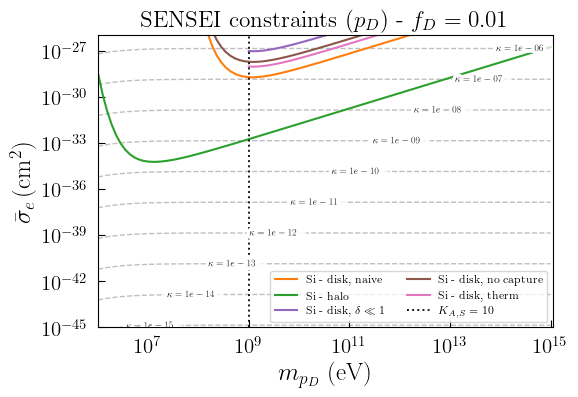

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0, 1.0, 10))




# for i in range(len(lim_massless)):
#     axs.plot(
#         masslist,
#         lim_massless[i],
#         label=targetlabels[i],
#         color=colors[i]
#     )

therm_val = 1e9
therm_ind = next(j for j, x in enumerate(masslist) if x >= therm_val)

for i in kept_indices:
    axs.plot(
        masslist[therm_ind:] if (i in therm_drops) else masslist,
        lim_massless[i][therm_ind:] if (i in therm_drops) else lim_massless[i],
        label=targetlabels[i],
        color=colors[i]
    )

axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e6, 1.1e15])
# axs.set_ylim([1e-49, 1.1e-26])
axs.set_ylim([1e-45, 1.1e-26])
axs.set_xlabel("$m_{p_D}$ (eV)", fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$", fontsize=18)
axs.tick_params(direction="in", which="both")

axs.set_title(r"SENSEI constraints ($p_D$) - $f_D = 0.01$")


# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)

# ------------------------------------------------------------------
# Labelled vertical line for legend
# ------------------------------------------------------------------

vline_x = therm_val

therm_line = axs.axvline(
    vline_x,
    color="black",
    lw=1.4,
    ls=":",
    alpha=0.9,
    zorder=2,
    # label=r"$m_{p_D}=1\,\mathrm{GeV}$"
)

# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
# main_handles = handles[:len(lim_massless)]
# main_labels = labels[:len(lim_massless)]
main_handles = handles[:len(kept_indices)]
main_labels = labels[:len(kept_indices)]

main_handles.append(therm_line)
main_labels.append(r"$K_{A,S} =10$")

axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="lower right"
)

fig.tight_layout()
fig.subplots_adjust(wspace=0.3)

### Now Nuclear

In [9]:
from millicharge_nr import attach_mc_nr_methods
attach_mc_nr_methods(darkelf)

def get_limit_nuclear(
    target,
    mX,
    material="Xe",
    mediator="massless",
    exposure=1,
    q_dm=1.0,
    kappa_ref=1e-9,
    ER_min_eV=None,
    ER_max_eV=None,
):
    target.update_params(mX=mX, mediator=mediator)

    R = target.R_mc(
        material=material,
        kappa=kappa_ref,
        q_dm=q_dm,
        vdist=target.vdist,
        ER_min_eV=ER_min_eV,
        ER_max_eV=ER_max_eV,
    )

    # if R == 0.0:
    #     return 1.0
    if (not np.isfinite(R)) or R <= 0.0:
        return np.inf
    else:
        return kappa_ref * np.sqrt(3.0 / (R * exposure))

In [ ]:
lim_massless_nuc=[]

# expXENON1T = 1000.0   # [kg-yr] = 1 tonne-year

# for target in target_list:
#     print(target.target)
#     lim_massless_nuc.append([
#         get_limit_nuclear(
#             target,
#             mX,
#             material="Xe",
#             mediator="massless",
#             exposure=expXENON1T,
#             q_dm=1.0,
#             ER_min_eV = 4.9e3,
#             ER_max_eV = 40.9e3 # 1805.12562
#         )
#         for mX in masslist
#     ])


expLZ = 3300.0   # [kg-yr] = 1 tonne-year

for target in target_list:
    print(target.target)
    lim_massless_nuc.append([
        get_limit_nuclear(
            target,
            mX,
            material="Xe",
            mediator="massless",
            exposure=expLZ,
            q_dm=1.0,
            ER_min_eV = 5.4e3,
            ER_max_eV = 54e3 # 2410.17036
        )
        for mX in masslist
    ])

lim_massless_nuc_DD = np.array(lim_massless_nuc)

lim_sigmae = [
    kappa_to_sigmae_exact(lim_massless_nuc[i], masslist)
    for i in range(len(lim_massless_nuc))
]

# use isotope 131 as reference
lim_sigmaN = [
    kappa_to_sigmaN_ref(lim_massless_nuc[i], masslist, 54.0, 131.0)
    for i in range(len(lim_massless_nuc))
]

lim_kappa_pD_N = lim_massless_nuc_DD

Si
Si
Si
Si
Si
Si
Si
Si


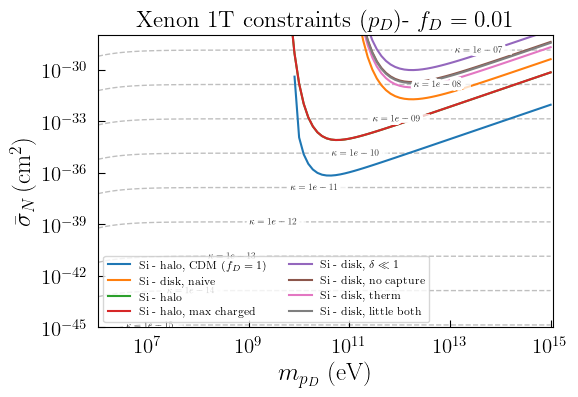

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_sigmae)):
    axs.plot(masslist,lim_sigmae[i],label=targetlabels[i],color=colors[i])
    
# for i in range(len(lim_sigmae)):
#     axs.plot(masslist,lim_sigmaN[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e6,1.1e15])
# axs.set_ylim([1e-49,1.1e-28])
axs.set_ylim([1e-45,1.1e-28])
axs.set_xlabel("$m_{p_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_N\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-21,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"Xenon 1T constraints ($p_D$)- $f_D = 0.01$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

############################# I THINK THIS IS THE ISSUE, I NEED TO BE USING THE CONVERSION FOR NUCLEI HERE RATHER THAN SIGMAE

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)



# ------------------------------------------------------------------
# Neutrino fog / floor (2109.03116)
# ------------------------------------------------------------------
 
# floor_file = "Xe_SI.txt"

# m_floor_GeV, sigma_floor_cm2 = np.loadtxt(floor_file, unpack=True)

# # If your x-axis is m_chi in eV:
# m_floor_eV = m_floor_GeV * 1e9

# # --- add to existing axes ---
# axs.plot(
#     m_floor_eV,
#     sigma_floor_cm2,
#     ls="--",
#     lw=2.0,
#     color="0.2",
#     alpha=0.7,
#     label=r"Xe SI $\nu$ floor"
# )


# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
main_handles = handles[:len(lim_massless_nuc)]
main_labels = labels[:len(lim_massless_nuc)]


axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="lower left"
)



fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
# labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
        #    ha='center',va='center',align=True,bbox=props)

move the damn legend

In [ ]:
smaller = [min(a, b) for a, b in zip(list1, list2)]

### Wimp comparison

In [ ]:
from millicharge_nr import attach_wimp_SI_nr_methods
attach_wimp_SI_nr_methods(darkelf)

In [ ]:
lim_wimp_SI_nuc = []

expXENON1T = 1000.0   # [kg-yr] = 1 tonne-year

for target, vinfo in zip(target_list, vs_list):
    print(target.target, vinfo["vdist"])

    lim_wimp_SI_nuc.append([
        target.sigma_n_limit_wimp_SI(
            material="Xe",
            exposure_kgyr=expXENON1T,
            n_limit=2.3,
            fp_over_fn=1.0,          # standard isospin-conserving SI WIMP
            vdist=vinfo["vdist"],    # use same halo/disk choice as the target
            ER_min_eV=4.9e3,
            ER_max_eV=40.9e3,        # XENON1T 1805.12562 NR ROI
            npts=800,
            sigma_ref_cm2=1e-45,
        )
        for mX in masslist
        for _ in [setattr(target, "mX", mX)]
    ])

lim_wimp_SI_nuc_DD = np.array(lim_wimp_SI_nuc)

Si halo
Si disk
Si disk
Si disk
Si disk
Si disk
Si disk


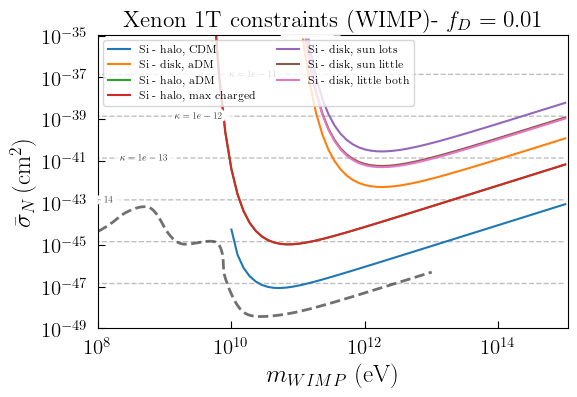

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_wimp_SI_nuc_DD)):
    axs.plot(masslist,lim_wimp_SI_nuc_DD[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e8,1.1e15])
axs.set_ylim([1e-49,1.1e-35])
axs.set_xlabel("$m_{WIMP}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_N\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-21,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"Xenon 1T constraints (WIMP)- $f_D = 0.01$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)



# ------------------------------------------------------------------
# Neutrino fog / floor (2109.03116)
# ------------------------------------------------------------------
 
floor_file = "Xe_SI.txt"

m_floor_GeV, sigma_floor_cm2 = np.loadtxt(floor_file, unpack=True)

# If your x-axis is m_chi in eV:
m_floor_eV = m_floor_GeV * 1e9

# --- add to existing axes ---
axs.plot(
    m_floor_eV,
    sigma_floor_cm2,
    ls="--",
    lw=2.0,
    color="0.2",
    alpha=0.7,
    label=r"Xe SI $\nu$ floor"
)


# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
main_handles = handles[:len(lim_wimp_SI_nuc_DD)]
main_labels = labels[:len(lim_wimp_SI_nuc_DD)]


axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="upper left"
)



fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
# labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
        #    ha='center',va='center',align=True,bbox=props)

The CDM line matches xenon wimp limits from eg fig 5 of 1805.12562

# Plot v dists - Dark Electron - SENSEI and Xenon Limits (22/4/26)

In [11]:
# masslist=np.logspace(3,10,100)

sqrtmrat = 1e2

# targetlabels=[r"Si - halo, CDM ($f_D=1$)","Si - disk, aDM","Si - halo, aDM","Si - halo, max charged","Si - disk, sun lots","Si - disk, sun little","Si - disk, little both"]
targetlabels=[r"Si - halo, CDM ($f_D=1$)","Si - disk, naive","Si - halo","Si - halo, max charged",r"Si - disk, $\delta \ll 1$","Si - disk, no capture","Si - disk, therm","Si - disk, little both"]

masslist_eD = masslist / sqrtmrat**2

kept_indices = (1,2,4,5)
therm_drops = (3,4)

In [12]:
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

# expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342
expDAMIC = 1.3 / 365 # [kg-yr] DAMIC exposure from 2503.14617

# need to divide fD by mass ratio to account for lower number density (dictated by dark proton mass rather than dark electron mass for fixed \rho_{DM})
fDcase = 0.01 / sqrtmrat**2 

vs_list = [{"v0kms": 220,"vesckms":500,"vekms":233,"vdist":"halo","fD":1,"therm":False},\
            {"v0kms":sqrtmrat * 20,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 30,"vdist":"disk","fD":fDcase,"therm":False},\
            {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":fDcase,"therm":False},\
            {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":fDcase,"therm":False},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":fDcase},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":30,"vdist":"disk","fD":fDcase,"therm":False},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":30,"vdist":"disk","fD":fDcase,"therm":False},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":30,"vdist":"disk","fD":fDcase,"therm":True},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":30,"vdist":"disk","fD":fDcase,"therm":False}] # all must be positive

target_list = [darkelf(target='Si',mX=mX,filename="Si_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],fD=v["fD"],therm=v["therm"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[0]))

etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[0]))



 .... Loading files for Si
Loaded Si_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Sun, H. Xu, B. Da, S.-f. Mao and Z.-j. Ding, Calculations of Energy-Loss Function for 26 Materials, Chinese Journal of Chemical Physics9(2016) 663.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensities,â in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554â595, https://onlinelibrary.wiley.com/doi/pdf/10.

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\mystuff/..\darkelf\__init__.py:680: RuntimeWarning: overflow encountered in sinh
  sinhca = sinh(a)/a
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\mystuff/..\darkelf\__init__.py:683: RuntimeWarning: invalid value encountered in scalar multiply
  (4*pi*v**2/self.Nfv_disk)
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\mystuff/..\darkelf\__init__.py:744: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  eta_full = quad(
c:\

In [13]:
# convert cm^2 ref cross-section to \kappa
# see eg (2.2) of 1509.01598

alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def sigmae_to_kappa_exact(sigmae_cm2, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = np.asarray(sigmae_cm2, dtype=float) / cm2_per_GeVminus2
    return (alpha * m_e_GeV**2 / (4*np.sqrt(np.pi)*mu)) * np.sqrt(sigmae_GeVminus2)

def kappa_to_sigmae_exact(kappa, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = (
        (4*np.sqrt(np.pi)*mu*kappa)/(alpha*m_e_GeV**2)
    )**2
    return sigmae_GeVminus2 * cm2_per_GeVminus2



In [14]:
# same as above for nuclear
# also from 1509.01598

def mu_chiN_GeV(mchi_eV, mN_GeV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * mN_GeV) / (mchi_GeV + mN_GeV)

def kappa_to_sigmaN_ref(kappa, mchi_eV, Z, mN_GeV, qref_GeV=None):
    """
    Reference DM-nucleus cross section for a massless kinetically mixed mediator.

    sigma_N(qref) = 16 pi alpha^2 kappa^2 Z^2 mu_chiN^2 / qref^4

    By default qref = alpha * m_e, matching the usual electron-reference convention.
    """
    if qref_GeV is None:
        qref_GeV = alpha * m_e_GeV

    muN = mu_chiN_GeV(mchi_eV, mN_GeV)

    sigmaN_GeVminus2 = (
        16 * np.pi * alpha**2
        * np.asarray(kappa, dtype=float)**2
        * Z**2
        * muN**2
        / qref_GeV**4
    )

    return sigmaN_GeVminus2 * cm2_per_GeVminus2

### electron recoil

In [15]:
task = ("write","read")[1]

# test_read = np.array([])

# fname = "lim_massless_SENSEI_exp_22_4_22"
# fname = "lim_massless_SENSEI_exp_11_5_26"
# fname = "lim_massless_SENSEI_exp_31_5_26"
# fname = "lim_massless_SENSEI_exp_1_6_26"
# fname = "lim_massless_SENSEI_exp_17_6_26"
# fname = "lim_massless_SENSEI_exp_therm_30_6_26"
fname = "lim_massless_DAMIC_exp_therm_09_07_26"


if task == "write":
    lim_massless=[]

    # expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342
    expDAMIC = 1.3 / 365 # [kg-yr] DAMIC exposure from 2503.14617

    # lim_massive=[]
    for target in target_list:
        print(target.target)
        # for v in vs_list:
        #     print(v)
        if target.target=="Al":
            # for Al, take 5 eV threshold
            lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless",exposure=expDAMIC) for mX in masslist_eD])
            # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
        else:
            # for the others, take the default threshold (2e- or 2 x bandgap)
            lim_massless.append([get_limit(target,mX,method="grid",mediator="massless",exposure=expDAMIC) for mX in masslist_eD])
            # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

    lim_massless_DD=np.array(lim_massless) 

    with open(fname, "wb") as f:
        pkl.dump(lim_massless,f)

elif task == "read":
    with open(fname, "rb") as f:
        lim_massless = pkl.load(f)

lim_kappa_eD_e = [sigmae_to_kappa_exact(lim_massless[i], masslist_eD) for i in range(len(lim_massless))]



NameError: name 'Line2D' is not defined

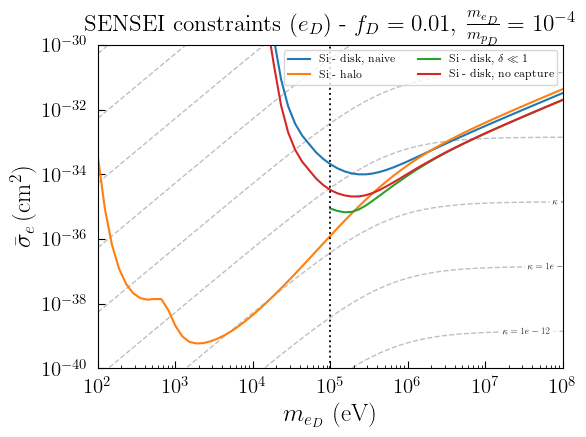

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

# cmap = plt.get_cmap('tab10')
# colors = cmap(np.linspace(0.0,1.0,10))
cmap = plt.get_cmap("tab10")
colors = {i: cmap(k) for k, i in enumerate(kept_indices)}
# colors[1], colors[2] = colors[2], colors[1]

# Case labels: your existing labels
case_labels = {i: targetlabels[i] for i in kept_indices}

# for i in range(len(lim_massless)):
#     axs.plot(masslist,lim_massless[i],label=targetlabels[i],color=colors[i])
    
    
# axs.set_xscale("log")   
# axs.set_yscale("log")

# axs.set_xlim([1e3,1.1e10])
# axs.set_ylim([1e-49,1.1e-26])


therm_val = 1e9 / sqrtmrat**2
therm_ind = next(j for j, x in enumerate(masslist_eD) if x >= therm_val)

# for i in kept_indices:
#     axs.plot(
#         masslist[therm_ind:] if (i in therm_drops) else masslist,
#         lim_massless[i][therm_ind:] if (i in therm_drops) else lim_massless[i],
#         label=targetlabels[i],
#         color=colors[i]
#     )
for i in kept_indices:
    axs.plot(
        masslist_eD[therm_ind:] if (i in therm_drops) else masslist_eD,
        lim_massless[i][therm_ind:] if (i in therm_drops) else lim_massless[i],
        label=targetlabels[i],
        color=colors[i]
    )

axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e2, 1.0e8])
# axs.set_ylim([1e-49, 1.1e-26])
# axs.set_ylim([1e-45, 1.1e-26])
axs.set_ylim([1e-40, 1.0e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"SENSEI constraints ($e_D$) - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist_eD)

    line, = axs.plot(
        masslist_eD,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e10, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)



# ------------------------------------------------------------------
# Labelled vertical line for legend
# ------------------------------------------------------------------

vline_x = therm_val

therm_line = axs.axvline(
    vline_x,
    color="black",
    lw=1.4,
    ls=":",
    alpha=0.9,
    zorder=2,
    # label=r"$m_{p_D}=1\,\mathrm{GeV}$"
)



# # ------------------------------------------------------------------
# # Main legend only for experimental / target curves
# # ------------------------------------------------------------------

# handles, labels = axs.get_legend_handles_labels()

# # keep only the original target curves in the legend
# # main_handles = handles[:len(lim_massless)]
# # main_labels = labels[:len(lim_massless)]
# main_handles = handles[:len(kept_indices)]
# main_labels = labels[:len(kept_indices)]

# main_handles.append(therm_line)
# main_labels.append(r"$K_{A,S} =10$")

# axs.legend(
#     main_handles,
#     main_labels,
#     ncol=2,
#     fontsize=8,
#     loc="lower right"
# )



# fig.tight_layout()
# fig.subplots_adjust(wspace = 0.3)


# props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
# lines = axs.get_lines()
# # labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
#         #    ha='center',va='center',align=True,bbox=props)



# ------------------------------------------------------------------
# Encoding legends
# ------------------------------------------------------------------
# Instead of one huge curve legend, make compact legends explaining the visual code.

case_handles = [
    Line2D(
        [0], [0],
        color=colors[i],
        lw=2.2,
        label=case_labels[i],
    )
    for i in kept_indices
]

# species_handles = [
#     Line2D(
#         [0], [0],
#         color="black",
#         lw=2.0,
#         ls=ls,
#         label=species,
#     )
#     for species, ls in species_styles.items()
# ]

# experiment_handles = [
#     Line2D(
#         [0], [0],
#         color="black",
#         # lw=2.0,
#         # alpha=alpha,
#         lw=lw,
#         label=experiment,
#     )
#     # for experiment, alpha in experiment_alphas.items()
#     for experiment, lw in experiment_lws.items()
# ]

# reference_handles = [
#     Line2D(
#         [0], [0],
#         color="purple",
#         lw=1.3,
#         ls="-",
#         label=r"$K_{A,S}=10$",
#     )
# ]



# reference_handles = [
#     Line2D(
#         [0], [0],
#         color="purple",
#         lw=1.3,
#         ls="-",
#         label=r"$K_{A,S}=10$",
#     ),
#     Line2D(
#         [0], [0],
#         color="purple",
#         lw=1.1,
#         ls="-",
#         alpha=0.6,
#         label=r"$K_{A,S}=1$",
#     )
# ]

reference_handles = []

leg1 = axs.legend(
    handles=case_handles,
    title="Cases",
    fontsize=8,
    title_fontsize=9,
    loc="lower right",
    frameon=False,
)

axs.add_artist(leg1)

# leg2 = ax.legend(
#     handles=species_handles + experiment_handles + reference_handles,
#     title="Encoding",
#     fontsize=8,
#     title_fontsize=9,
#     loc="lower right",
#     frameon=False,
# )

# fig.tight_layout()
# fig.subplots_adjust(wspace=0.3)
fig.subplots_adjust(
    left=0.13,
    right=0.97,
    bottom=0.15,
    top=0.90,
)
plt.show()

### Now Nuclear

In [16]:
from millicharge_nr import attach_mc_nr_methods
attach_mc_nr_methods(darkelf)

def get_limit_nuclear(
    target,
    mX,
    material="Xe",
    mediator="massless",
    exposure=1,
    q_dm=1.0,
    kappa_ref=1e-9,
    ER_min_eV=None,
    ER_max_eV=None,
):
    target.update_params(mX=mX, mediator=mediator)

    R = target.R_mc(
        material=material,
        kappa=kappa_ref,
        q_dm=q_dm,
        vdist=target.vdist,
        ER_min_eV=ER_min_eV,
        ER_max_eV=ER_max_eV,
    )

    if R == 0.0:
        return 1.0
    else:
        return kappa_ref * np.sqrt(3.0 / (R * exposure))

In [17]:
lim_massless=[]

# expXENON1T = 1000.0   # [kg-yr] = 1 tonne-year

# for target in target_list:
#     print(target.target)
#     lim_massless.append([
#         get_limit_nuclear(
#             target,
#             mX,
#             material="Xe",
#             mediator="massless",
#             exposure=expXENON1T,
#             q_dm=1.0,
#         )
#         for mX in masslist_eD
#     ])


expLZ = 3300.0   # [kg-yr] = 1 tonne-year

for target in target_list:
    print(target.target)
    lim_massless.append([
        get_limit_nuclear(
            target,
            mX,
            material="Xe",
            mediator="massless",
            exposure=expLZ,
            q_dm=1.0,
            ER_min_eV = 5.4e3,
            ER_max_eV = 54e3 # 2410.17036
        )
        for mX in masslist_eD
    ])

lim_massless_DD = np.array(lim_massless)



Si
Si
Si
Si
Si
Si
Si
Si


In [18]:
alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def kappa_to_sigmae_exact(kappa, mchi_eV):
    """
    Inverse of sigmae_to_kappa_exact using the same convention:
        kappa = (alpha m_e^2 / (4 sqrt(pi) mu)) * sqrt(sigmae)

    Therefore:
        sigmae = [4 sqrt(pi) mu kappa / (alpha m_e^2)]^2

    Inputs
    ------
    kappa : float or array
        Millicharge / kinetic-mixing parameter in your convention.
    mchi_eV : float or array
        DM mass in eV.

    Returns
    -------
    sigmae_cm2 : float or array
        Reference electron cross section in cm^2
    """
    mu = mu_chie_GeV(mchi_eV)

    pref = (4*np.sqrt(np.pi) * mu * np.asarray(kappa, dtype=float)) / (alpha * m_e_GeV**2)

    sigmae_GeVminus2 = pref**2

    return sigmae_GeVminus2 * cm2_per_GeVminus2


# Example: convert your kappa-limit arrays back to sigmae arrays
lim_sigmae = [
    kappa_to_sigmae_exact(lim_massless[i], masslist)
    for i in range(len(lim_massless))
]

lim_kappa_eD_N = lim_massless

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 5 in `xvals` is outside the range of its associated line (xmin=np.float64(999.999999999999), xmax=np.float64(10000000000.0), xval=24494897427.831787). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 6 in `xvals` is outside the range of its associated line (xmin=np.float64(999.999999999999), xmax=np.float64(10000000000.0), xval=160947691199.96503). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 7 in `xvals` is outside the range of its associated line (xmin=np.float64(999.9999999

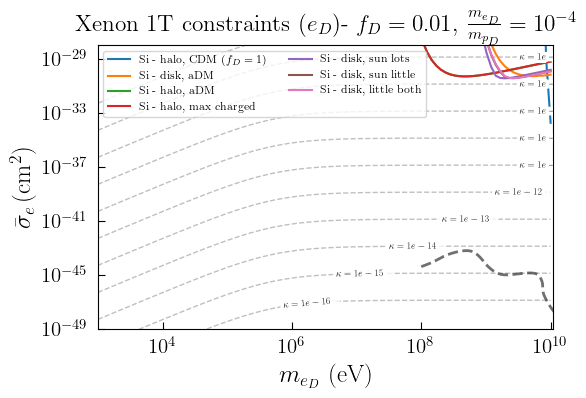

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_sigmae)):
    axs.plot(masslist,lim_sigmae[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-49,1.1e-28])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-21,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"Xenon 1T constraints ($e_D$)- $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)



# ------------------------------------------------------------------
# Neutrino fog / floor (2109.03116)
# ------------------------------------------------------------------
 
floor_file = "Xe_SI.txt"

m_floor_GeV, sigma_floor_cm2 = np.loadtxt(floor_file, unpack=True)

# If your x-axis is m_chi in eV:
m_floor_eV = m_floor_GeV * 1e9

# --- add to existing axes ---
axs.plot(
    m_floor_eV,
    sigma_floor_cm2,
    ls="--",
    lw=2.0,
    color="0.2",
    alpha=0.7,
    label=r"Xe SI $\nu$ floor"
)


# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
main_handles = handles[:len(lim_massless_nuc)]
main_labels = labels[:len(lim_massless_nuc)]


axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="upper left"
)


fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
#labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
#           ha='center',va='center',align=True,bbox=props)

compare to mtwh paper and nuclear recoil plots

# Atomic Halo Case

In [19]:

kcut=1.2e4 # restrict phase space for massive mediator


targetlabels=["Halo, Atomic"]


masslist_pD = masslist

sqrtmrat = 1e2


In [ ]:

mX=1.0e8 # specify the dark matter mass (to be updated later)

# expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342
expDAMIC = 1.3 / 365 # [kg-yr] DAMIC exposure from 2503.14617

vs_list = [{"v0kms":220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01,"with_atomic_ff":True,"therm":False}] # all must be positive
# vs_list = [{"v0kms":220,"vesckms": 544,"vekms": 233,"vdist":"halo","fD":0.01,"with_atomic_ff":True}] # all must be positive




target_list = [darkelf(target='Si',mX=mX,filename="Si_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],fD=v["fD"],with_atomic_ff=v["with_atomic_ff"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

# flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
# flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[0]))

# etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
# etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[0]))



 .... Loading files for Si
Loaded Si_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Sun, H. Xu, B. Da, S.-f. Mao and Z.-j. Ding, Calculations of Energy-Loss Function for 26 Materials, Chinese Journal of Chemical Physics9(2016) 663.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensities,â in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554â595, https://onlinelibrary.wiley.com/doi/pdf/10.

In [ ]:
# convert cm^2 ref electron cross-section to \kappa
# see eg (2.2) of 1509.01598

alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def sigmae_to_kappa_exact(sigmae_cm2, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = np.asarray(sigmae_cm2, dtype=float) / cm2_per_GeVminus2
    return (alpha * m_e_GeV**2 / (4*np.sqrt(np.pi)*mu)) * np.sqrt(sigmae_GeVminus2)

def kappa_to_sigmae_exact(kappa, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = (
        (4*np.sqrt(np.pi)*mu*kappa)/(alpha*m_e_GeV**2)
    )**2
    return sigmae_GeVminus2 * cm2_per_GeVminus2

In [ ]:
# same as above for nuclear
# also from 1509.01598

def mu_chiN_GeV(mchi_eV, mN_GeV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * mN_GeV) / (mchi_GeV + mN_GeV)

def kappa_to_sigmaN_ref(kappa, mchi_eV, Z, mN_GeV, qref_GeV=None):
    """
    Reference DM-nucleus cross section for a massless kinetically mixed mediator.

    sigma_N(qref) = 16 pi alpha^2 kappa^2 Z^2 mu_chiN^2 / qref^4

    By default qref = alpha * m_e, matching the usual electron-reference convention.
    """
    if qref_GeV is None:
        qref_GeV = alpha * m_e_GeV

    muN = mu_chiN_GeV(mchi_eV, mN_GeV)

    sigmaN_GeVminus2 = (
        16 * np.pi * alpha**2
        * np.asarray(kappa, dtype=float)**2
        * Z**2
        * muN**2
        / qref_GeV**4
    )

    return sigmaN_GeVminus2 * cm2_per_GeVminus2

### electron recoil

In [ ]:
def get_limit_AFF(target,mX,threshold=-1.0,method="grid",mediator="massless",kcut=0.0,exposure=1,with_atomic_ff=False, alpha_D=1/137, mrat=1e4):
    
    target.update_params(mX=mX,mediator=mediator)

    # with_atomic_ff=False, alpha_D=None, m_eD_eV=None, m_pD_eV=None
    
    if target.with_atomic_ff:
        R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut,vdist=target.vdist,with_atomic_ff=target.with_atomic_ff,alpha_D=alpha_D, m_eD_eV=mX / mrat, m_pD_eV=mX)
    else:
        R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut,vdist=target.vdist)

    if R==0.0:
        return 1.0
    else:
        return 3.0*1.0e-38/(R*exposure) # exposure in kg-year (default 1)

In [ ]:
task = ("write","read")[0]

# test_read = np.array([])

# fname = "lim_massless_SENSEI_exp_atomic_17_6_26"
# fname = "lim_massless_SENSEI_exp_atomic_18_6_26"
# fname = "lim_massless_SENSEI_exp_atomic_29_6_26"
fname = "lim_massless_DAMIC_exp_atomic_09_07_26"

if task == "write":

    lim_massless=[]

    # expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342
    expDAMIC = 1.3 / 365 # [kg-yr] DAMIC exposure from 2503.14617

    # lim_massive=[]
    for target in target_list:
        print(target.target)
        # for v in vs_list:
        #     print(v)
        if target.target=="Al":
            # for Al, take 5 eV threshold
            lim_massless.append([get_limit_AFF(target,mX,threshold=5.0,method="grid",mediator="massless",exposure=expDAMIC,with_atomic_ff=target.with_atomic_ff,
                                alpha_D=alpha,
                                mrat=sqrtmrat**2) 
                                for mX in masslist])
            # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
        else:
            # for the others, take the default threshold (2e- or 2 x bandgap)
            lim_massless.append([get_limit_AFF(target,mX,method="grid",mediator="massless",exposure=expDAMIC,with_atomic_ff=target.with_atomic_ff,
                                alpha_D=alpha,
                                mrat=sqrtmrat**2) 
                                for mX in masslist])
            # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

    lim_massless_DD=np.array(lim_massless) 

    with open(fname, "wb") as f:
        pkl.dump(lim_massless,f)

elif task == "read":
    with open(fname, "rb") as f:
        lim_massless = pkl.load(f)


lim_kappa_atomic_e = [sigmae_to_kappa_exact(lim_massless[i], masslist) for i in range(len(lim_massless))]

Si


### nuclear recoil

In [ ]:
from millicharge_nr import attach_mc_nr_methods
attach_mc_nr_methods(darkelf)

def get_limit_nuclear(
    target,
    mX,
    material="Xe",
    mediator="massless",
    exposure=1,
    q_dm=1.0,
    kappa_ref=1e-9,
    ER_min_eV=None,
    ER_max_eV=None,
    with_atomic_ff=False,
    alpha_D=1/137, 
    mrat=1e4,
):
    target.update_params(mX=mX, mediator=mediator)

    R = target.R_mc(
        material=material,
        kappa=kappa_ref,
        q_dm=q_dm,
        vdist=target.vdist,
        ER_min_eV=ER_min_eV,
        ER_max_eV=ER_max_eV,
        with_atomic_ff=with_atomic_ff,
        alpha_D=alpha_D,
        m_eD_eV=mX / mrat,
        m_pD_eV=mX,
    )

    # if R == 0.0:
    #     return 1.0
    if (not np.isfinite(R)) or R <= 0.0:
        return np.inf
    else:
        return kappa_ref * np.sqrt(3.0 / (R * exposure))

In [ ]:
lim_massless_nuc=[]

expXENON1T = 1000.0   # [kg-yr] = 1 tonne-year

for target in target_list:
    print(target.target)
    lim_massless_nuc.append([
        get_limit_nuclear(
            target,
            mX,
            material="Xe",
            mediator="massless",
            exposure=expXENON1T,
            q_dm=1.0,
            ER_min_eV = 4.9e3,
            ER_max_eV = 40.9e3, # 1805.12562,
            with_atomic_ff=target.with_atomic_ff,
            alpha_D=alpha,
            mrat=sqrtmrat**2,
        )
        for mX in masslist
    ])

lim_massless_nuc_DD = np.array(lim_massless_nuc)

lim_sigmae = [
    kappa_to_sigmae_exact(lim_massless_nuc[i], masslist)
    for i in range(len(lim_massless_nuc))
]

# use isotope 131 as reference
lim_sigmaN = [
    kappa_to_sigmaN_ref(lim_massless_nuc[i], masslist, 54.0, 131.0)
    for i in range(len(lim_massless_nuc))
]

lim_kappa_atomic_N = lim_massless_nuc_DD

Si


# Plot v dists - Dark Electron (1e-2 mrat) - SENSEI and Xenon Limits (7/5/26)

In [ ]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later

sqrtmrat = 1e1

expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

targetlabels=[r"Si - halo, CDM ($f_D=1$)","Si - disk, aDM","Si - halo, aDM","Si - halo, max charged","Si - disk, sun lots","Si - disk, sun little","Si - disk, little both"]

# need to divide fD by mass ratio to account for lower number density (dictated by dark proton mass rather than dark electron mass for fixed \rho_{DM})
fDcase = 0.01 / sqrtmrat**2 

vs_list = [{"v0kms": 220,"vesckms":500,"vekms":233,"vdist":"halo","fD":fDcase},
            {"v0kms":sqrtmrat * 20,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 30,"vdist":"disk","fD":fDcase},\
            {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":fDcase},\
            {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":fDcase},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":30,"vdist":"disk","fD":fDcase},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":30,"vdist":"disk","fD":fDcase},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":30,"vdist":"disk","fD":fDcase}] # all must be positive

target_list = [darkelf(target='Si',mX=mX,filename="Si_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],fD=v["fD"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[0]))

etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[0]))



 .... Loading files for Si
Loaded Si_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Sun, H. Xu, B. Da, S.-f. Mao and Z.-j. Ding, Calculations of Energy-Loss Function for 26 Materials, Chinese Journal of Chemical Physics9(2016) 663.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensities,â in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554â595, https://onlinelibrary.wiley.com/doi/pdf/10.

In [ ]:
# convert cm^2 ref cross-section to \kappa
# see eg (2.2) of 1509.01598

alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def sigmae_to_kappa_exact(sigmae_cm2, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = np.asarray(sigmae_cm2, dtype=float) / cm2_per_GeVminus2
    return (alpha * m_e_GeV**2 / (4*np.sqrt(np.pi)*mu)) * np.sqrt(sigmae_GeVminus2)

def kappa_to_sigmae_exact(kappa, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = (
        (4*np.sqrt(np.pi)*mu*kappa)/(alpha*m_e_GeV**2)
    )**2
    return sigmae_GeVminus2 * cm2_per_GeVminus2

### electron recoil

In [ ]:
task = ("write","read")[1]

# test_read = np.array([])

# fname = "lim_massless_SENSEI_exp_sqrtmrat_1e1_7_5_26"
fname = "lim_massless_SENSEI_exp_sqrtmrat_1e1_11_5_26"

if task == "write":
    lim_massless=[]

    expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

    # lim_massive=[]
    for target in target_list:
        print(target.target)
        # for v in vs_list:
        #     print(v)
        if target.target=="Al":
            # for Al, take 5 eV threshold
            lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist])
            # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
        else:
            # for the others, take the default threshold (2e- or 2 x bandgap)
            lim_massless.append([get_limit(target,mX,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist])
            # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

    lim_massless_DD=np.array(lim_massless) 

    with open(fname, "wb") as f:
        pkl.dump(lim_massless,f)

elif task == "read":
    with open(fname, "rb") as f:
        lim_massless = pkl.load(f)

NameError: name 'pkl' is not defined

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 5 in `xvals` is outside the range of its associated line (xmin=np.float64(999.999999999999), xmax=np.float64(10000000000.0), xval=24494897427.831787). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 6 in `xvals` is outside the range of its associated line (xmin=np.float64(999.999999999999), xmax=np.float64(10000000000.0), xval=160947691199.96503). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 7 in `xvals` is outside the range of its associated line (xmin=np.float64(999.9999999

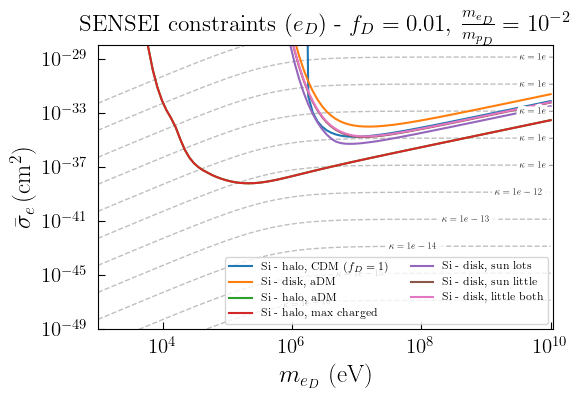

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_massless)):
    axs.plot(masslist,lim_massless[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-49,1.1e-28])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"SENSEI constraints ($e_D$) - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-2}$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)




# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
main_handles = handles[:len(lim_massless)]
main_labels = labels[:len(lim_massless)]


axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="lower right"
)



fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
# labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
        #    ha='center',va='center',align=True,bbox=props)

### Now Nuclear

In [ ]:
from millicharge_nr import attach_mc_nr_methods
attach_mc_nr_methods(darkelf)

def get_limit_nuclear(
    target,
    mX,
    material="Xe",
    mediator="massless",
    exposure=1,
    q_dm=1.0,
    kappa_ref=1e-9,
    ER_min_eV=None,
    ER_max_eV=None,
):
    target.update_params(mX=mX, mediator=mediator)

    R = target.R_mc(
        material=material,
        kappa=kappa_ref,
        q_dm=q_dm,
        vdist=target.vdist,
        ER_min_eV=ER_min_eV,
        ER_max_eV=ER_max_eV,
    )

    if R == 0.0:
        return 1.0
    else:
        return kappa_ref * np.sqrt(3.0 / (R * exposure))

In [ ]:
lim_massless=[]

expXENON1T = 1000.0   # [kg-yr] = 1 tonne-year

for target in target_list:
    print(target.target)
    lim_massless.append([
        get_limit_nuclear(
            target,
            mX,
            material="Xe",
            mediator="massless",
            exposure=expXENON1T,
            q_dm=1.0,
        )
        for mX in masslist
    ])

lim_massless_DD = np.array(lim_massless)

# Example: convert your kappa-limit arrays back to sigmae arrays
lim_sigmae = [
    kappa_to_sigmae_exact(lim_massless[i], masslist)
    for i in range(len(lim_massless))
]

Si
Si
Si
Si
Si
Si
Si


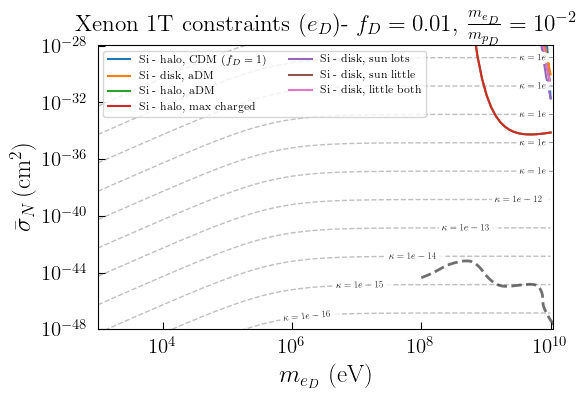

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_sigmae)):
    axs.plot(masslist,lim_sigmae[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-28])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_N\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-21,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"Xenon 1T constraints ($e_D$)- $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-2}$")



# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------



# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist)

    line, = axs.plot(
        masslist,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        label=rf"$\kappa={kap:.0e}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
xvals_kappa = np.geomspace(2e6, 3e14, len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)



# ------------------------------------------------------------------
# Neutrino fog / floor (2109.03116)
# ------------------------------------------------------------------
 
floor_file = "Xe_SI.txt"

m_floor_GeV, sigma_floor_cm2 = np.loadtxt(floor_file, unpack=True)

# If your x-axis is m_chi in eV:
m_floor_eV = m_floor_GeV * 1e9

# --- add to existing axes ---
axs.plot(
    m_floor_eV,
    sigma_floor_cm2,
    ls="--",
    lw=2.0,
    color="0.2",
    alpha=0.7,
    label=r"Xe SI $\nu$ floor"
)


# ------------------------------------------------------------------
# Main legend only for experimental / target curves
# ------------------------------------------------------------------

handles, labels = axs.get_legend_handles_labels()

# keep only the original target curves in the legend
main_handles = handles[:len(lim_massless)]
main_labels = labels[:len(lim_massless)]


axs.legend(
    main_handles,
    main_labels,
    ncol=2,
    fontsize=8,
    loc="upper left"
)


fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
#labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
#           ha='center',va='center',align=True,bbox=props)

# combined plots for paper

### initialize

In [63]:


# targetlabels=[r"Si - halo, CDM ($f_D=1$)","Si - disk, naive","Si - halo","Si - halo, max charged",r"Si - disk, $\delta \ll 1$","Si - disk, no capture","Si - disk, little both"]

targetlabels=[r"Si - halo, CDM ($f_D=1$)","Disk, Naive","halo","halo, max charged",r"Disk, Case B","Disk, Case A and C","Disk, Case C","Si - disk, little both"]


# kept_indices = (1,2,4,5)
kept_indices = (1,4,5,6)
therm_drops = (3,4,5,6)

# Scenario controls line style
scenario_styles = {
    kept_indices[0]: ":",
    kept_indices[1]: "-",
    kept_indices[2]: "--",
    kept_indices[3]: "--",
    # kept_indices[3]: (0, (1, 1)),
}

sqrtmrat=1e2


In [64]:
from matplotlib.lines import Line2D
import json
from matplotlib.ticker import FuncFormatter, LogFormatterMathtext
from matplotlib.transforms import ScaledTranslation

# Optional but strongly recommended:
# pip install adjustText
try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False


# ------------------------------------------------------------------
# User inputs / style maps
# ------------------------------------------------------------------



# therm_val = 10**8.92479
therm_val = 0.95e9
therm_ind = next(j for j, x in enumerate(masslist) if x >= therm_val)

# cmap = plt.get_cmap("tab10")
# colors = {i: cmap(k) for k, i in enumerate(kept_indices)}
# colors[1], colors[2] = colors[2], colors[1]

# # Case labels: your existing labels
case_labels = {i: targetlabels[i] for i in kept_indices}

# # Species controls line style
# species_styles = {
#     r"$p_D$": "--",
#     r"$e_D$": "-",
# }

# # Experiment controls line width
# experiment_lws = {
#     "SENSEI": 2.2,
#     "Xenon1T": 1.1,
# }



# Species controls line width
species_lws = {
    r"$p_D$": 1.2,
    r"$e_D$": 3.0,
}

# Experiment controls color
cmap = plt.get_cmap("tab10")
experiment_colors = {
    "DAMIC": "b",# cmap(0),
    "Xenon1T": "r", #cmap(1),
    "OSCURA": "c", # for OSCURA
}


# expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342
expDAMIC = 1.3 / 365 # [kg-yr] DAMIC exposure from 2503.14617
expOSCURA = 30 # [kg-yr] projected exposure from 2202.10518
eR_rescale = expDAMIC / expOSCURA

# Each entry should be indexed by case i:
#
#   ydata[i] = constraint curve for case i
#
datasets = [
    {
        "species": r"$p_D$",
        "experiment": "DAMIC",
        "ydata": lim_kappa_pD_e,
        "mass": masslist,
    },
    {
        "species": r"$p_D$",
        "experiment": "Xenon1T",
        "ydata": lim_kappa_pD_N,
        "mass": masslist,
    },
    {
        "species": r"$p_D$",
        "experiment": "OSCURA",
        "ydata": sigmae_to_kappa_exact(kappa_to_sigmae_exact(np.array(lim_kappa_pD_e),masslist) * eR_rescale,masslist),
        "mass": masslist,
    },
    {
        "species": r"$e_D$",
        "experiment": "DAMIC",
        "ydata": lim_kappa_eD_e,
        "mass": masslist,
    },
    {
        "species": r"$e_D$",
        "experiment": "Xenon1T",
        "ydata": lim_kappa_eD_N,
        "mass": masslist,
    },
    {
        "species": r"$e_D$",
        "experiment": "OSCURA",
        "ydata": sigmae_to_kappa_exact(kappa_to_sigmae_exact(np.array(lim_kappa_eD_e),masslist) * eR_rescale,masslist),
        "mass": masslist,
    },
]





In [ ]:
def finite_positive_xy(x, y):
    """
    Keep only points valid on a log-log plot.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    return x[mask], y[mask]


def maybe_apply_thermal_cut(x, y, case_index, therm_drops, therm_ind, cut_above=True):
    """
    Apply the thermal cutoff only to cases listed in therm_drops.
    """
    if case_index in therm_drops:
        if cut_above:
            return x[:therm_ind+1], y[:therm_ind+1]
        else:
            return x[therm_ind:], y[therm_ind:]
    return x, y


def choose_label_point(x, y, frac=0.78):
    """
    Pick a point along the curve for the direct label.
    frac=0.78 places labels near the right side but not exactly at the endpoint.
    """
    if len(x) == 0:
        return None, None

    j = int(frac * (len(x) - 1))
    return x[j], y[j]

def load_log_contour_from_json(filename, index):
    """
    Load one contour branch from K_SM_E_contours.json.

    File format:
        [
            [[log10_x1, log10_y1], [log10_x2, log10_y2], ...],
            [[log10_x1, log10_y1], [log10_x2, log10_y2], ...]
        ]

    Returns:
        x = 10**log10_x
        y = 10**log10_y
    """
    with open(filename, "r") as f:
        data = json.load(f)

    arr = np.asarray(data[index], dtype=float)

    logx = arr[:, 0]
    logy = arr[:, 1]

    x = 10.0**logx
    y = 10.0**logy

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)

    return x[mask], y[mask]


def shade_above_contour(ax, x, y, y_upper, color="gray", alpha=0.15, zorder=0):
    """
    Shade the region above a contour y(x).

    Assumes x and y are already in physical units, not log units.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Sort by x so fill_between behaves correctly
    order = np.argsort(x)
    x = x[order]
    y = y[order]

    ax.fill_between(
        x,
        y,
        y_upper,
        color=color,
        alpha=alpha,
        zorder=zorder,
    )

### Extract Cosmo Constraints

In [ ]:
import fitz  # pymupdf
# import numpy as np
# import matplotlib.pyplot as plt
from matplotlib.path import Path
import pandas as pd

pdf_file = "MCPplot.pdf"
doc = fitz.open(pdf_file)
page = doc[0]
drawings = page.get_drawings()

# ------------------------------------------------------------------
# Plot box calibration from the PDF coordinates
# ------------------------------------------------------------------
# These are approximate from the rendered PDF.
# Tune slightly if the overlay is shifted.
x_pdf_left   = 45.296997
x_pdf_right  = 395.5
y_pdf_top    = 5.625
y_pdf_bottom = 355.828

x_data_min, x_data_max = 2, 14
y_data_min, y_data_max = -14, 0

def pdf_to_data(xpdf, ypdf):
    x = x_data_min + (xpdf - x_pdf_left) / (x_pdf_right - x_pdf_left) * (x_data_max - x_data_min)
    y = y_data_min + (y_pdf_bottom - ypdf) / (y_pdf_bottom - y_pdf_top) * (y_data_max - y_data_min)
    return x, y

In [ ]:
def sample_cubic(p0, p1, p2, p3, n=40):
    t = np.linspace(0, 1, n)
    pts = (
        (1 - t)[:, None]**3 * np.array([p0.x, p0.y])
        + 3 * (1 - t)[:, None]**2 * t[:, None] * np.array([p1.x, p1.y])
        + 3 * (1 - t)[:, None] * t[:, None]**2 * np.array([p2.x, p2.y])
        + t[:, None]**3 * np.array([p3.x, p3.y])
    )
    return pts

def drawing_to_polygon_data(d, n_bezier=40):
    pts_pdf = []

    for item in d["items"]:
        kind = item[0]

        if kind == "l":
            p0, p1 = item[1], item[2]
            pts_pdf.append([p0.x, p0.y])
            pts_pdf.append([p1.x, p1.y])

        elif kind == "c":
            p0, p1, p2, p3 = item[1], item[2], item[3], item[4]
            pts_pdf.extend(sample_cubic(p0, p1, p2, p3, n=n_bezier))

        elif kind == "re":
            # Rectangle
            r = item[1]
            pts_pdf.extend([
                [r.x0, r.y0],
                [r.x1, r.y0],
                [r.x1, r.y1],
                [r.x0, r.y1],
                [r.x0, r.y0],
            ])

    if len(pts_pdf) < 3:
        return None

    pts_pdf = np.array(pts_pdf, dtype=float)
    x, y = pdf_to_data(pts_pdf[:, 0], pts_pdf[:, 1])
    pts_data = np.column_stack([x, y])

    return pts_data

In [ ]:
polygons = []

for i, d in enumerate(drawings):
    fill = d.get("fill")
    if fill is None:
        continue

    fill = np.array(fill)

    # Skip nearly white or nearly black/gray objects if desired.
    # Colored regions usually have non-equal RGB components.
    is_gray = np.max(fill) - np.min(fill) < 0.03
    is_white = np.all(fill > 0.95)

    if is_gray or is_white:
        continue

    pts = drawing_to_polygon_data(d)
    if pts is None:
        continue

    # Keep only objects with some overlap with the data range
    x, y = pts[:, 0], pts[:, 1]
    overlaps_plot = (
        x.max() >= x_data_min and x.min() <= x_data_max and
        y.max() >= y_data_min and y.min() <= y_data_max
    )
    if not overlaps_plot:
        continue

    # Rough area filter to avoid tiny labels/markers
    area_box = (x.max() - x.min()) * (y.max() - y.min())
    if area_box < 0.02:
        continue

    polygons.append(pts)

print(f"Kept {len(polygons)} filled colored polygons")

Kept 11 filled colored polygons


In [ ]:
# ------------------------------------------------------------------
# Rasterize union in log-coordinate data space
# ------------------------------------------------------------------

Nx, Ny = 1800, 1800   # increase for more precision

xgrid = np.linspace(x_data_min, x_data_max, Nx)
ygrid = np.linspace(y_data_min, y_data_max, Ny)

X, Y = np.meshgrid(xgrid, ygrid)
points = np.column_stack([X.ravel(), Y.ravel()])

union_mask = np.zeros(points.shape[0], dtype=bool)

for pts in polygons:
    path = Path(pts)
    union_mask |= path.contains_points(points)

union_mask = union_mask.reshape(Y.shape)

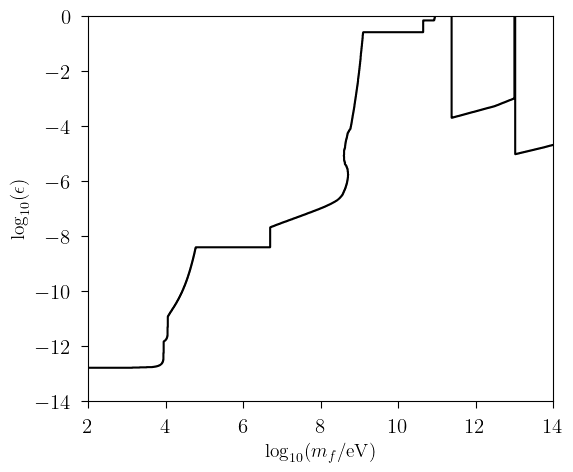

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))

cs = ax.contour(
    X,
    Y,
    union_mask.astype(float),
    levels=[0.5],
    colors="k",
    linewidths=1.5,
)

ax.set_xlim(2, 14)
ax.set_ylim(-14, 0)
ax.set_xlabel(r"$\log_{10}(m_f/\mathrm{eV})$")
ax.set_ylabel(r"$\log_{10}(\epsilon)$")

plt.show()

### money plot

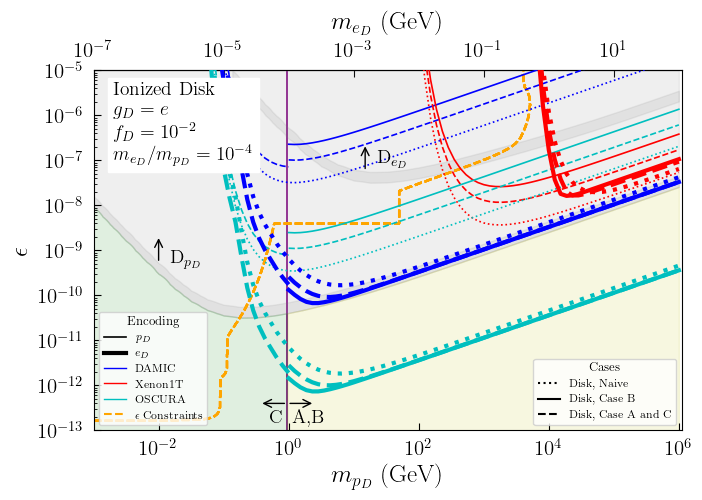

In [ ]:
fig, ax = plt.subplots(figsize=(7.0, 4.8))

texts = []


# therm_val = 10**8.92479
therm_val = 0.95e9
therm_ind = next(j for j, x in enumerate(masslist) if x >= therm_val)


for data in datasets:
    species = data["species"]
    experiment = data["experiment"]
    ydata = data["ydata"]
    xdata = np.asarray(data["mass"], dtype=float)

    # ls = species_styles[species]
    # alpha = experiment_alphas[experiment]
    # lw = experiment_lws[experiment]

    for i in kept_indices:
        x = xdata
        y = np.asarray(ydata[i], dtype=float)

        x, y = maybe_apply_thermal_cut(x, y, i, therm_drops, therm_ind, True if case_labels[i]=="Disk, Case C" else False)
        x, y = finite_positive_xy(x, y)

        if len(x) < 2:
            continue

        ax.plot(
        x,
        y,
        color=experiment_colors[experiment],
        ls=scenario_styles[i],
        lw=species_lws[species],
        zorder=3,
)



# ------------------------------------------------------------------
# Axes
# ------------------------------------------------------------------

ax.set_xscale("log")
ax.set_yscale("log")

xlims = [1e6, 1.1e15]
ylims = [1e-13, 1.0e-5]

ax.set_xlim(xlims)
ax.set_ylim(ylims)


# ax.text(2e6,3e-7,"Ionized Disk \n $f_D=10^{-2}$ \n $m_{p_D}/m_{e_D}=10^4$",fontsize=14,backgroundcolor="white",horizontalalignment="left")
ax.text(2e6,1e-7,"Ionized Disk \n $g_D = e$ \n $f_D=10^{-2}$ \n $m_{e_D}/m_{p_D}=10^{-4}$",fontsize=14,backgroundcolor="white",horizontalalignment="left")


eVtoGeV = 10**(-9)
ax.xaxis.set_major_formatter(
    lambda value, position: LogFormatterMathtext()(eVtoGeV * value)
)

ax.set_xlabel(r"$m_{p_D}$ (GeV)", fontsize=18)
# ax.set_ylabel(r"$\kappa$", fontsize=18)
ax.set_ylabel(r"$\epsilon$", fontsize=18)
ax.tick_params(direction="in", which="both")

# ax.set_title(r"$\kappa$ constraints, $f_D = 0.01$")

y_upper = ax.get_ylim()[1]


# ------------------------------------------------------------------
# Ambient Thermalization Line
# ------------------------------------------------------------------

therm_line = ax.axvline(
    therm_val,
    color="purple",
    lw=1.3,
    ls="-",
    alpha=0.9,
    zorder=1,
)

# therm_line = ax.axvline(
#     10**8.58272,
#     color="purple",
#     lw=1.1,
#     ls="-",
#     alpha=0.6,
#     zorder=1,
# )


# ------------------------------------------------------------------
# Extra contours from JSON (p_D SS)
# ------------------------------------------------------------------

contour_file = "K_SM_E_contours.json"

x_c1, y_c1 = load_log_contour_from_json(contour_file, 0)
x_c2, y_c2 = load_log_contour_from_json(contour_file, 1)



# Fill between contours
xmin = max(np.min(x_c1), np.min(x_c2))
xmax = min(np.max(x_c1), np.max(x_c2))

x_common = np.logspace(
    np.log10(xmin),
    np.log10(xmax),
    1000,
)

y1_common = np.interp(x_common, x_c1, y_c1)
y2_common = np.interp(x_common, x_c2, y_c2)

# ax.plot(x_c1, y_c1)
# ax.plot(x2, y2)

ax.fill_between(
    x_common,
    y1_common,
    y2_common,
    alpha=0.12,
    zorder=1,
    color="gray"
)


# ------------------------------------------------------------------
# Shade Regions
# ------------------------------------------------------------------

# Region D
ax.fill_between(
    x_common,
    y1_common,
    ylims[1],
    alpha=0.12,
    zorder=1,
    color="gray"
)

# Regions A,B
contour_therm_ind = next(j for j, x in enumerate(x_common) if x >= therm_val)

ax.fill_between(
    x_common[contour_therm_ind:],
    y1_common[contour_therm_ind:],
    ylims[0],
    alpha=0.12,
    zorder=1,
    color="y"
)


# Regions C
contour_therm_ind = next(j for j, x in enumerate(x_common) if x >= therm_val)

ax.fill_between(
    x_common[:contour_therm_ind],
    y1_common[:contour_therm_ind],
    ylims[0],
    alpha=0.12,
    zorder=1,
    color="g"
)


# ------------------------------------------------------------------
# Label and point to regions
# ------------------------------------------------------------------

# D region Arrow

xpos = 1e-2/eVtoGeV

pos_ind = next(j for j, x in enumerate(x_common) if x >= xpos)

angle = 90          # degrees
length = 20         # points

dx = length * np.cos(np.deg2rad(angle))
dy = length * np.sin(np.deg2rad(angle))


ax.annotate(
    "",
    xy=(xpos, y2_common[pos_ind]),
    xytext=(dx, dy),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="<-"),
)

ax.text(1.5 * xpos,y2_common[pos_ind],r"D$_{p_D}$",fontsize=14,horizontalalignment="left")


# C region Arrow

xpos = therm_val

angle = 180          # degrees
length = 20         # points

dx = length * np.cos(np.deg2rad(angle))
dy = length * np.sin(np.deg2rad(angle))


ax.annotate(
    "",
    xy=(xpos, 4e-13),
    xytext=(dx, dy),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="<-"),
)

ax.text(0.55 * xpos,1.5e-13,"C",fontsize=14,horizontalalignment="left")

# C region Arrow

xpos = therm_val

angle = 0          # degrees
length = 20         # points

dx = length * np.cos(np.deg2rad(angle))
dy = length * np.sin(np.deg2rad(angle))


ax.annotate(
    "",
    xy=(xpos, 4e-13),
    xytext=(dx, dy),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="<-"),
)


ax.text(1.2 * xpos,1.5e-13,"A,B",fontsize=14,horizontalalignment="left")



# ------------------------------------------------------------------
# Extra contours from JSON (eD SS)
# ------------------------------------------------------------------

contour_file = "K_SM_E_contours_Disk_eD.json"

x_c1, y_c1 = load_log_contour_from_json(contour_file, 0)
x_c2, y_c2 = load_log_contour_from_json(contour_file, 1)


# Fill between contours
xmin = max(np.min(x_c1), np.min(x_c2))
xmax = min(np.max(x_c1), np.max(x_c2))

x_common = np.logspace(
    np.log10(xmin),
    np.log10(xmax),
    1000,
)

y1_common = np.interp(x_common, x_c1, y_c1)
y2_common = np.interp(x_common, x_c2, y_c2)

# ax.plot(x_c1, y_c1)
# ax.plot(x2, y2)

ax.fill_between(
    x_common,
    y1_common,
    y2_common,
    alpha=0.12,
    zorder=1,
    color="gray"
)



# ------------------------------------------------------------------
# Label and point to regions (eD SS)
# ------------------------------------------------------------------

# D region Arrow

xpos = 1.5e1/eVtoGeV

pos_ind = next(j for j, x in enumerate(x_common) if x >= xpos)

angle = 90          # degrees
length = 20         # points

dx = length * np.cos(np.deg2rad(angle))
dy = length * np.sin(np.deg2rad(angle))


ax.annotate(
    "",
    xy=(xpos, y2_common[pos_ind]),
    xytext=(dx, dy),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="<-"),
)

ax.text(1.5 * xpos,1.5 * y2_common[pos_ind],r"D$_{e_D}$",fontsize=14,horizontalalignment="left")


# ------------------------------------------------------------------
# Secondary top x-axis
# ------------------------------------------------------------------

mrat = eVtoGeV * 1.0 / sqrtmrat**2 

def bottom_to_top(x):
    return mrat * x

def top_to_bottom(x_top):
    return x_top / mrat

secax = ax.secondary_xaxis(
    "top",
    functions=(bottom_to_top, top_to_bottom),
)

secax.set_xscale("log")
secax.set_xlabel(r"$m_{e_D}$ (GeV)", fontsize=18,labelpad=10)
secax.tick_params(direction="in", which="both")

# ------------------------------------------------------------------
# Automatically adjust labels
# ------------------------------------------------------------------

if HAS_ADJUSTTEXT:
    adjust_text(
        texts,
        ax=ax,

        # Keep labels from flying sideways across the plot
        only_move={
            "text": "y",
            "static": "y",
            "explode": "y",
            "pull": "y",
        },

        # Much gentler adjustment
        force_text=(0.02, 0.15),
        force_static=(0.02, 0.15),
        force_pull=(0.005, 0.02),

        # Do not allow huge excursions
        max_move=(0, 8),

        # No arrows. This avoids the FancyArrowPatch warning.
        arrowprops=None,

        # Fewer iterations; prevents pathological rearrangements
        iter_lim=100,
    )

# ------------------------------------------------------------------
# cosmo contours from 1311.2600
# ------------------------------------------------------------------

cs = ax.contour(
    10**X * sqrtmrat**2,
    10**Y,
    union_mask.astype(float),
    # levels=[0.5],
    colors="orange",
    linewidths=1.5,
    linestyles="--",
)


# ------------------------------------------------------------------
# Legends
# ------------------------------------------------------------------


case_handles = [
    Line2D(
        [0], [0],
        # color=colors[i],
        color="black",
        ls=scenario_styles[i],
        label=case_labels[i],
    )
    for i in kept_indices[:-1]
]

species_handles = [
    Line2D(
        [0], [0],
        color="black",
        lw=lw,
        ls="-",
        label=species,
    )
    for species, lw in species_lws.items()
]

experiment_handles = [
    Line2D(
        [0], [0],
        # color="black",
        color=experiment_colors[experiment],
        # lw=2.0,
        # alpha=alpha,
        lw=1.0,
        label=experiment,
    )
    # for experiment, alpha in experiment_alphas.items()
    for experiment, color in experiment_colors.items()
]


cosmo_handles = [
    Line2D(
        [0], [0],
        color="orange",
        lw=1.5,
        ls="--",
        label=r"$\epsilon$ Constraints"
    )
    ]

reference_handles = []

leg1 = ax.legend(
    handles=case_handles,
    title="Cases",
    fontsize=8,
    title_fontsize=9,
    loc="lower right",
    # frameon=False,
    frameon=True,
    facecolor="white"
)

ax.add_artist(leg1)

leg2 = ax.legend(
    handles=species_handles + experiment_handles + reference_handles+cosmo_handles,
    title="Encoding",
    fontsize=8,
    title_fontsize=9,
    loc="lower left",
    # frameon=False,
    frameon=True,
    facecolor="white"
)

# fig.tight_layout()
# fig.subplots_adjust(wspace=0.3)
fig.subplots_adjust(
    left=0.13,
    right=0.97,
    bottom=0.15,
    top=0.90,
)

fig.savefig(
   "plots/for_paper_30_6_26/money_disk.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

### electrons only 

In [65]:

# targetlabels=[r"Si - halo, CDM ($f_D=1$)","Si - disk, aDM","Si - halo, aDM","Si - halo, max charged","Si - disk, sun lots","Si - disk, sun little","Si - disk, little both"]
targetlabels=[r"Si - halo, CDM ($f_D=1$)","Disk, Naive","Halo, Ionized","Si - halo, max charged","Disk, Case B","Disk, Case A and C","Disk, Case C","Si - disk, little both"]

masslist_eD = masslist / sqrtmrat**2

kept_indices = (1,2,4,5,6)
therm_drops = (3,4,5,6)

halo_index = (2)

# Scenario controls line style
scenario_styles = {
    kept_indices[0]: ":",
    kept_indices[1]: "-.",
    kept_indices[2]: "-",
    kept_indices[3]: "--",
    kept_indices[4]: "--",
    # kept_indices[3]: (0, (1, 1)),
}



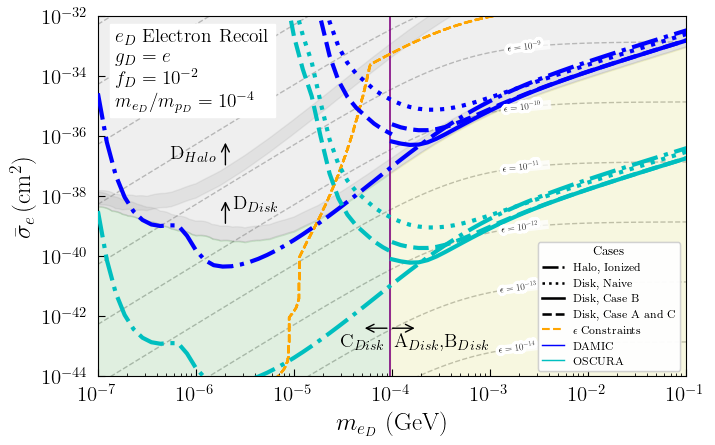

In [66]:
# fig, axs = plt.subplots(figsize=(6,4.2))
# fig, axs = plt.subplots(figsize=(7.0, 4.8))
fig, axs = plt.subplots(figsize=(7.0, 4.8))

# cmap = plt.get_cmap('tab10')
# colors = cmap(np.linspace(0.0,1.0,10))
cmap = plt.get_cmap("tab10")
# colors = {i: cmap(k) for k, i in enumerate(kept_indices)}
# colors[1], colors[2] = colors[2], colors[1]

# Case labels: your existing labels
case_labels = {i: targetlabels[i] for i in kept_indices}


# therm_val = 1e9 / sqrtmrat**2
therm_val = 0.95e9 / sqrtmrat**2
therm_ind = next(j for j, x in enumerate(masslist_eD) if x >= therm_val)


### SENSEI

spc_lw = species_lws[r"$e_D$"]
# exp_color = experiment_colors["SENSEI"]
exp_color = experiment_colors["DAMIC"]


lim_data = next(
    # (item.get("ydata") for item in datasets if item.get("species") == r"$e_D$" and item.get("experiment") == "SENSEI"),
    (item.get("ydata") for item in datasets if item.get("species") == r"$e_D$" and item.get("experiment") == "DAMIC"),
    None
)

lim_data = kappa_to_sigmae_exact(lim_data, masslist_eD)


for i in kept_indices:
    # axs.plot(
    #     masslist_eD[therm_ind:] if (i in therm_drops) else masslist_eD,
    #     lim_data[i][therm_ind:] if (i in therm_drops) else lim_data[i],
    #     label=targetlabels[i],
    #     color=exp_color,
    #     lw=spc_lw,
    #     ls=scenario_styles[i],
    # )

    x = masslist_eD
    y = np.asarray(lim_data[i], dtype=float)

    x, y = maybe_apply_thermal_cut(x, y, i, therm_drops, therm_ind, True if case_labels[i]=="Disk, Case C" else False)
    x, y = finite_positive_xy(x, y)

    if len(x) < 2:
        continue

    axs.plot(
        x,
        y,
        label=targetlabels[i],
        color=exp_color,
        ls=scenario_styles[i],
        lw=spc_lw,
        zorder=3,
    )
    


### OSCURA

spc_lw = species_lws[r"$e_D$"]
exp_color = experiment_colors["OSCURA"]


lim_data = next(
    (item.get("ydata") for item in datasets if item.get("species") == r"$e_D$" and item.get("experiment") == "OSCURA"),
    None
)

lim_data = kappa_to_sigmae_exact(lim_data, masslist_eD)


for i in kept_indices:
    # axs.plot(
    #     masslist_eD[therm_ind:] if (i in therm_drops) else masslist_eD,
    #     lim_data[i][therm_ind:] if (i in therm_drops) else lim_data[i],
    #     label=targetlabels[i],
    #     color=exp_color,
    #     lw=spc_lw,
    #     ls=scenario_styles[i],
    # )
    
    x = masslist_eD
    y = np.asarray(lim_data[i], dtype=float)

    x, y = maybe_apply_thermal_cut(x, y, i, therm_drops, therm_ind, True if case_labels[i]=="Disk, Case C" else False)
    x, y = finite_positive_xy(x, y)

    if len(x) < 2:
        continue

    axs.plot(
        x,
        y,
        label=targetlabels[i],
        color=exp_color,
        ls=scenario_styles[i],
        lw=spc_lw,
        zorder=3,
    )



# ------------------------------------------------------------------
# Axes
# ------------------------------------------------------------------

axs.set_xscale("log")   
axs.set_yscale("log")

xlims = [1e2, 1.0e8]
ylims = [1e-44, 1.0e-32]

# axs.set_xlim([eVtoGeV * 1e2, eVtoGeV * 1.0e8])
axs.set_xlim(xlims)
axs.set_ylim(ylims)


# last_tick = axs.get_xticks()[-2]

# def hide_last_tick(x, pos):
#     if np.isclose(x, last_tick):
#         return ""
#     exponent = int(np.round(np.log10(x)))
#     return rf"$10^{{{exponent}}}$"

# axs.xaxis.set_major_formatter(FuncFormatter(hide_last_tick))

# axs.xaxis.set_label_coords(0.47, -0.10)

# fig.canvas.draw()

# major_ticks = axs.xaxis.get_major_ticks()

# for i, tick in enumerate(major_ticks):
#     print(i, tick.get_loc(), tick.label1.get_text())

# # Remove the label at the upper plot boundary, x = 1e8
# major_ticks[7].label1.set_visible(False)

# fig.canvas.draw()

# xmax = axs.get_xlim()[1]

# for tick in axs.xaxis.get_major_ticks():
#     if np.isclose(tick.get_loc(), xmax):
#         tick.label1.set_transform(
#             tick.label1.get_transform()
#             # + ScaledTranslation(-32 / 72, 0, fig.dpi_scale_trans)
#             + ScaledTranslation(-10, 0, fig.dpi_scale_trans)
#         )

# xmax = axs.get_xlim()[1]
# boundary_text = None

# for tick in axs.xaxis.get_major_ticks():
#     if np.isclose(tick.get_loc(), xmax):
#         boundary_text = tick.label1.get_text()
#         tick.label1.set_visible(False)

# axs.text(
#     0.985,                  # slightly left of right boundary
#     -0.035,                 # vertical tick-label position
#     boundary_text,
#     transform=axs.transAxes,
#     ha="right",
#     va="top",
# )

# axs.text(1.5e2,5e-35,"$e_{D}$ Electron Recoil\n $f_D=10^{-2}$ \n $m_{p_D}/m_{e_D}=10^4$",fontsize=14,backgroundcolor="white",horizontalalignment="left")
axs.text(1.5e2,1e-35,"$e_{D}$ Electron Recoil\n $g_D=e$ \n $f_D=10^{-2}$ \n $m_{e_D}/m_{p_D}=10^{-4}$",fontsize=14,backgroundcolor="white",horizontalalignment="left")

eVtoGeV = 10**(-9)
axs.xaxis.set_major_formatter(
    lambda value, position: LogFormatterMathtext()(eVtoGeV * value)
)

# axs.set_xscale("log")   
# axs.set_yscale("log")

axs.set_xlabel("$m_{e_D}$ (GeV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")


# labels = axs.get_xticklabels()
# labels[-1].set_visible(False)
# fig.canvas.draw()
# axs.xaxis.get_offset_text().set_visible(False)

# import numpy as np
# from matplotlib.ticker import FuncFormatter


axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title(r"SENSEI ($e_D$) - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")



# ------------------------------------------------------------------
# Extra contours from JSON
# ------------------------------------------------------------------

contour_file = "K_SM_E_contours.json"

x_c1, y_c1 = load_log_contour_from_json(contour_file, 0)
x_c2, y_c2 = load_log_contour_from_json(contour_file, 1)


# Fill between contours
xmin = max(np.min(x_c1), np.min(x_c2)) * eVtoGeV * 1e-4
xmax = min(np.max(x_c1), np.max(x_c2)) * eVtoGeV * 1e-4

x_common = np.logspace(
    np.log10(xmin),
    np.log10(xmax),
    1000,
)

y1_common = np.interp(x_common, x_c1 * eVtoGeV * 1e-4, y_c1)
y2_common = np.interp(x_common, x_c2 * eVtoGeV * 1e-4, y_c2)

# ax.plot(x_c1, y_c1)
# ax.plot(x2, y2)

sigma_1_common = kappa_to_sigmae_exact(y1_common, x_common / (eVtoGeV))
sigma_2_common = kappa_to_sigmae_exact(y2_common, x_common / (eVtoGeV))

# ax.fill_between(
#     x_common,
#     y1_common,
#     y2_common,
#     alpha=0.12,
#     zorder=1,
# )


axs.fill_between(
    x_common / (eVtoGeV),
    sigma_1_common,
    sigma_2_common,
    alpha=0.12,
    zorder=1,
    color="gray",
)


# ------------------------------------------------------------------
# Shade Regions
# ------------------------------------------------------------------

# sigma_1_common

# Region D
axs.fill_between(
    x_common / (eVtoGeV),
    sigma_1_common,
    ylims[1],
    alpha=0.12,
    zorder=1,
    color="gray"
)

# Regions A,B
contour_therm_ind = next(j for j, x in enumerate(x_common / (eVtoGeV)) if x >= therm_val)

axs.fill_between(
    x_common[contour_therm_ind:] / (eVtoGeV),
    ylims[0],
    sigma_1_common[contour_therm_ind:],
    alpha=0.12,
    zorder=1,
    color="y"
)


# Regions C
contour_therm_ind = next(j for j, x in enumerate(x_common / (eVtoGeV)) if x >= therm_val)

axs.fill_between(
    x_common[:contour_therm_ind] / (eVtoGeV),
    ylims[0],
    sigma_1_common[:contour_therm_ind],
    alpha=0.12,
    zorder=1,
    color="g"
)


# ------------------------------------------------------------------
# Label and point to regions
# ------------------------------------------------------------------

# D region Arrow

xpos = 2e-6

pos_ind = next(j for j, x in enumerate(x_common) if x >= xpos)

angle = 90          # degrees
length = 20         # points

dx = length * np.cos(np.deg2rad(angle))
dy = length * np.sin(np.deg2rad(angle))


axs.annotate(
    "",
    xy=(xpos/eVtoGeV, sigma_2_common[pos_ind]),
    xytext=(dx, dy),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="<-"),
)

axs.text(1.2 * xpos/eVtoGeV,4 * sigma_2_common[pos_ind],r"D$_{Disk}$",fontsize=14,horizontalalignment="left")

# print([1.5 * xpos/eVtoGeV,sigma_2_common[pos_ind]])

# C region Arrow

xpos = therm_val

angle = 180          # degrees
length = 20         # points

dx = length * np.cos(np.deg2rad(angle))
dy = length * np.sin(np.deg2rad(angle))


axs.annotate(
    "",
    xy=(xpos, 4e-43),
    xytext=(dx, dy),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="<-"),
)

# axs.text(0.7 * xpos,1e-43,"C",fontsize=14,horizontalalignment="left")
axs.text(0.9 * xpos,1e-43,r"C$_{Disk}$",fontsize=14,horizontalalignment="right")

# C region Arrow

xpos = therm_val

angle = 0          # degrees
length = 20         # points

dx = length * np.cos(np.deg2rad(angle))
dy = length * np.sin(np.deg2rad(angle))


axs.annotate(
    "",
    xy=(xpos, 4e-43),
    xytext=(dx, dy),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="<-"),
)


# axs.text(1.1 * xpos,1e-43,"A,B",fontsize=14,horizontalalignment="left")
axs.text(1.1 * xpos,1e-43,r"A$_{Disk}$,B$_{Disk}$",fontsize=14,horizontalalignment="left")



# ------------------------------------------------------------------
# Extra contours from JSON - Halo
# ------------------------------------------------------------------

contour_file = "K_SM_E_contours_Halo.json"

x_c1, y_c1 = load_log_contour_from_json(contour_file, 0)
x_c2, y_c2 = load_log_contour_from_json(contour_file, 1)



# Fill between contours
xmin = max(np.min(x_c1), np.min(x_c2)) * eVtoGeV * 1e-4
xmax = min(np.max(x_c1), np.max(x_c2)) * eVtoGeV * 1e-4

x_common = np.logspace(
    np.log10(xmin),
    np.log10(xmax),
    1000,
)

y1_common = np.interp(x_common, x_c1 * eVtoGeV * 1e-4, y_c1)
y2_common = np.interp(x_common, x_c2 * eVtoGeV * 1e-4, y_c2)

# ax.plot(x_c1, y_c1)
# ax.plot(x2, y2)

sigma_1_common = kappa_to_sigmae_exact(y1_common, x_common / (eVtoGeV))
sigma_2_common = kappa_to_sigmae_exact(y2_common, x_common / (eVtoGeV))

# ax.fill_between(
#     x_common,
#     y1_common,
#     y2_common,
#     alpha=0.12,
#     zorder=1,
# )


axs.fill_between(
    x_common / (eVtoGeV),
    sigma_1_common,
    sigma_2_common,
    alpha=0.12,
    zorder=1,
    color="gray",
)



# ------------------------------------------------------------------
# Label and point to regions (Halo)
# ------------------------------------------------------------------

# D region Arrow

xpos = 2e-6

pos_ind = next(j for j, x in enumerate(x_common) if x >= xpos)

angle = 90          # degrees
length = 20         # points

dx = length * np.cos(np.deg2rad(angle))
dy = length * np.sin(np.deg2rad(angle))


axs.annotate(
    "",
    xy=(xpos/eVtoGeV, sigma_2_common[pos_ind]),
    xytext=(dx, dy),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="<-"),
)

axs.text(0.8 * xpos/eVtoGeV,2 * sigma_2_common[pos_ind],r"D$_{Halo}$",fontsize=14,horizontalalignment="right")

# print([1.5 * xpos/eVtoGeV,sigma_2_common[pos_ind]])


# ------------------------------------------------------------------
# cosmo contours from 1311.2600
# ------------------------------------------------------------------

cs = axs.contour(
    10**X,
    kappa_to_sigmae_exact(10**Y, 10**X),
    union_mask.astype(float),
    # levels=[0.5],
    colors="orange",
    linewidths=1.5,
    linestyles="--",
)

# ------------------------------------------------------------------
# Vertical reference line
# ------------------------------------------------------------------

therm_line = axs.axvline(
    therm_val,
    color="purple",
    lw=1.3,
    ls="-",
    alpha=0.9,
    zorder=1,
)

# therm_line = axs.axvline(
#     eVtoGeV * 10**8.58272 / sqrtmrat**2,
#     color="purple",
#     lw=1.1,
#     ls="-",
#     alpha=0.6,
#     zorder=1,
# )


# therm_line = axs.axvline(
#     10**8.58272 / sqrtmrat**2,
#     color="purple",
#     lw=1.1,
#     ls="-",
#     alpha=0.6,
#     zorder=1,
# )


# ------------------------------------------------------------------
# Constant-kappa contours on the sigma plot
# ------------------------------------------------------------------

# Choose kappa values to display
kappa_contours = np.array([
    1e-16,
    1e-15,
    1e-14,
    1e-13,
    1e-12,
    1e-11,
    1e-10,
    1e-9,
    1e-8,
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3
])

kappa_lines = []

for kap in kappa_contours:
    sig_line = kappa_to_sigmae_exact(kap, masslist_eD)
    
    exponent = int(np.round(np.log10(kap)))

    line, = axs.plot(
        masslist_eD,
        sig_line,
        color="black",
        alpha=0.25,
        lw=1.0,
        ls="--",
        zorder=0.5,
        # label=rf"$\kappa={kap:.0e}$"
        # label=rf"$\epsilon={kap:.0e}$"
        label=rf"$\epsilon=10^{{{exponent}}}$"
    )

    kappa_lines.append(line)


# ------------------------------------------------------------------
# Label the kappa contour lines
# ------------------------------------------------------------------

props_kappa = dict(
    facecolor="white",
    alpha=0.75,
    edgecolor="none",
    boxstyle="square,pad=0.02"
)

# Pick x-positions for the labels.
# You can tune these by hand if labels overlap.
# xvals_kappa = np.geomspace(2e6 * eVtoGeV, 3e6 * eVtoGeV, len(kappa_lines))
xvals_kappa = np.geomspace(2e6 , 3e6 , len(kappa_lines))

labelLines(
    kappa_lines,
    xvals=xvals_kappa,
    fontsize=7,
    zorder=3,
    ha="center",
    va="center",
    align=True,
    bbox=props_kappa
)


# ------------------------------------------------------------------
# Legends
# ------------------------------------------------------------------

case_handles_order_swap = [kept_indices[j] for j in (1,0,2,3)]

case_handles = [
    Line2D(
        [0], [0],
        color="k",
        lw=1.8,
        ls=scenario_styles[i],
        label=case_labels[i],
    )
    # for i in kept_indices
    for i in case_handles_order_swap
]




cosmo_handles = [
    Line2D(
        [0], [0],
        color="orange",
        lw=1.5,
        ls="--",
        label=r"$\epsilon$ Constraints"
    )
    ]

experiment_handles = [
    Line2D(
        [0], [0],
        # color="black",
        color=experiment_colors[experiment],
        # lw=2.0,
        # alpha=alpha,
        lw=1.0,
        label=experiment,
    )
    # for experiment, alpha in experiment_alphas.items()
    for experiment, color in experiment_colors.items()
    if experiment != "Xenon1T"
]

reference_handles = []

leg1 = axs.legend(
    handles=case_handles+cosmo_handles+experiment_handles,
    title="Cases",
    fontsize=8,
    title_fontsize=9,
    loc="lower right",
    # frameon=False,
    frameon=True,
    facecolor="white"
)

axs.add_artist(leg1)

fig.subplots_adjust(
    left=0.13,
    right=0.97,
    bottom=0.15,
    top=0.90,
)


fig.savefig(
    "plots/for_paper_30_6_26/money_eD.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()

In [67]:
from align_plot_pdf import align_pdf

# align right plot border to a reference plot

align_pdf(
    source="plots/for_paper_30_6_26/money_eD.pdf",
    reference="plots/for_paper_30_6_26/money_disk.pdf",
    output="plots/for_paper_30_6_26/money_eD_aligned.pdf",
)

Saved: plots\for_paper_30_6_26\money_eD_aligned.pdf
Left crop:  3.300 pt
Right crop: 5.830 pt
Final width: 505.924 pt


### Money Plot Halo and atomic

In [68]:
targetlabels=[r"Si - halo, CDM ($f_D=1$)","Si - disk, aDM","Halo, Ionized","Si - halo, max charged","Si - disk, sun lots","Si - disk, sun little","disk, therm","Si - disk, little both","Halo, Atomic"]
# targetlabels=["Halo, Ionized","Halo, Atomic"]

# masslist_eD = masslist / sqrtmrat**2

kept_indices = [2]
kept_indices_atomic = [-1]
therm_drops = (3,4,5,6)

# halo_index = (2)

# Scenario controls line style
# scenario_styles = {
#     kept_indices[0]: "-",
#     kept_indices_atomic[0]: "--"
# }
species_styles = {
    "Atomic":"-",
    r"$e_D$":"--",
    r"$p_D$":":",
}

In [69]:
datasets_atomic = [
    {
        "species": "Atomic",
        "experiment": "DAMIC",
        "ydata": lim_kappa_atomic_e,
        "mass": masslist,
    },
    {
        "species": "Atomic",
        "experiment": "Xenon1T",
        # "ydata": lim_kappa_atomic_N,
        "ydata" : np.array([[1 if el == float('inf') else el for el in lim_kappa_atomic_N[0]]]),
        "mass": masslist,
    },
    {
        "species": "Atomic",
        "experiment": "OSCURA",
        "ydata": sigmae_to_kappa_exact(kappa_to_sigmae_exact(np.array(lim_kappa_atomic_e),masslist) * eR_rescale,masslist),
        "mass": masslist,
    },
]

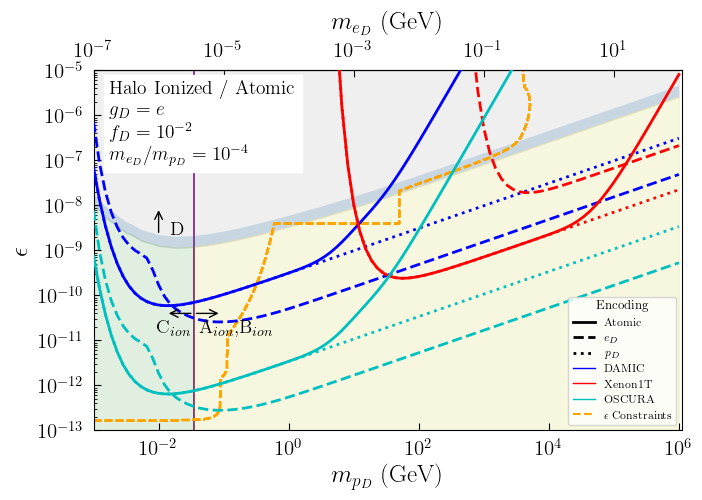

In [70]:
fig, ax = plt.subplots(figsize=(7.0, 4.8))

texts = []


# Case labels: your existing labels
case_labels = {i: targetlabels[i] for i in kept_indices+kept_indices_atomic}


# therm_val = 10**8.92479
# therm_val = 0.95e9
therm_val = 10**(7.54)
therm_ind = next(j for j, x in enumerate(masslist) if x >= therm_val)


for data in datasets:
    species = data["species"]
    experiment = data["experiment"]
    ydata = data["ydata"]
    xdata = np.asarray(data["mass"], dtype=float)

    # ls = species_styles[species]
    # alpha = experiment_alphas[experiment]
    # lw = experiment_lws[experiment]

    for i in kept_indices:
    # if True:
        # i = halo_index

        x = xdata
        y = np.asarray(ydata[i], dtype=float)

        x, y = maybe_apply_thermal_cut(x, y, i, therm_drops, therm_ind)
        x, y = finite_positive_xy(x, y)

        if len(x) < 2:
            continue

        ax.plot(
        x,
        y,
        color=experiment_colors[experiment],
        # ls=scenario_styles[i],
        ls=species_styles[species],
        # lw=species_lws[species],
        lw=2.0,
        zorder=3,
)



for data in datasets_atomic:
    species = data["species"]
    experiment = data["experiment"]
    ydata = data["ydata"]
    xdata = np.asarray(data["mass"], dtype=float)

    # ls = species_styles[species]
    # alpha = experiment_alphas[experiment]
    # lw = experiment_lws[experiment]

    for i in kept_indices_atomic:
    # if True:
        # i = halo_index

        x = xdata
        y = np.asarray(ydata[i], dtype=float)

        x, y = maybe_apply_thermal_cut(x, y, i, therm_drops, therm_ind)
        x, y = finite_positive_xy(x, y)

        if len(x) < 2:
            continue

        ax.plot(
        x,
        y,
        color=experiment_colors[experiment],
        # ls=scenario_styles[i],
        ls=species_styles[species],
        # lw=species_lws[r"$e_D$"],
        lw=2.0,
        zorder=3,
)


# ------------------------------------------------------------------
# Vertical reference line
# ------------------------------------------------------------------

therm_line = ax.axvline(
    therm_val,
    color="purple",
    lw=1.3,
    ls="-",
    alpha=0.9,
    zorder=1,
)

# therm_line = ax.axvline(
#     10**7.20,
#     color="purple",
#     lw=1.1,
#     ls="-",
#     alpha=0.6,
#     zorder=1,
# )


# ------------------------------------------------------------------
# Axes
# ------------------------------------------------------------------

ax.set_xscale("log")
ax.set_yscale("log")

xlims = [1e6, 1.1e15]
ylims = [1e-13, 1.0e-5]

ax.set_xlim(xlims)
ax.set_ylim(ylims)


# ax.text(1.75e6,3e-7,"Halo\n $g_D=e$ \n $f_D=10^{-2}$ \n $m_{p_D}/m_{e_D}=10^4$",fontsize=14,backgroundcolor="white",horizontalalignment="left")
ax.text(1.75e6,1e-7,"Halo Ionized / Atomic\n $g_D=e$ \n $f_D=10^{-2}$ \n $m_{e_D}/m_{p_D}=10^{-4}$",fontsize=14,backgroundcolor="white",horizontalalignment="left")


eVtoGeV = 10**(-9)
ax.xaxis.set_major_formatter(
    lambda value, position: LogFormatterMathtext()(eVtoGeV * value)
)


ax.set_xlabel(r"$m_{p_D}$ (GeV)", fontsize=18)
# ax.set_ylabel(r"$\kappa$", fontsize=18)
ax.set_ylabel(r"$\epsilon$", fontsize=18)
ax.tick_params(direction="in", which="both")

# ax.set_title(r"$\kappa$ constraints, $f_D = 0.01$")

y_upper = ax.get_ylim()[1]

# ------------------------------------------------------------------
# Extra contours from JSON (ionized)
# ------------------------------------------------------------------

contour_file = "K_SM_E_contours_Halo.json"

x_c1, y_c1 = load_log_contour_from_json(contour_file, 0)
x_c2, y_c2 = load_log_contour_from_json(contour_file, 1)

# Fill between contours
xmin = max(np.min(x_c1), np.min(x_c2))
xmax = min(np.max(x_c1), np.max(x_c2))

x_common = np.logspace(
    np.log10(xmin),
    np.log10(xmax),
    1000,
)

y1_common = np.interp(x_common, x_c1, y_c1)
y2_common = np.interp(x_common, x_c2, y_c2)

# ax.plot(x_c1, y_c1)
# ax.plot(x2, y2)

ax.fill_between(
    x_common,
    y1_common,
    y2_common,
    alpha=0.20,
    zorder=1,
)


# ------------------------------------------------------------------
# Shade Regions
# ------------------------------------------------------------------


# Region D
ax.fill_between(
    x_common,
    y1_common,
    ylims[1],
    alpha=0.12,
    zorder=1,
    color="gray"
)

# Regions A,B
contour_therm_ind = next(j for j, x in enumerate(x_common) if x >= therm_val)

ax.fill_between(
    x_common[contour_therm_ind:],
    y1_common[contour_therm_ind:],
    ylims[0],
    alpha=0.12,
    zorder=1,
    color="y"
)


# Regions C
contour_therm_ind = next(j for j, x in enumerate(x_common) if x >= therm_val)

ax.fill_between(
    x_common[:contour_therm_ind],
    y1_common[:contour_therm_ind],
    ylims[0],
    alpha=0.12,
    zorder=1,
    color="g"
)


# ------------------------------------------------------------------
# Label and point to regions
# ------------------------------------------------------------------

# D region Arrow

xpos = 1e-2/eVtoGeV

pos_ind = next(j for j, x in enumerate(x_common) if x >= xpos)

angle = 90          # degrees
length = 20         # points

dx = length * np.cos(np.deg2rad(angle))
dy = length * np.sin(np.deg2rad(angle))


ax.annotate(
    "",
    xy=(xpos, y2_common[pos_ind]),
    xytext=(dx, dy),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="<-"),
)

ax.text(1.5 * xpos,y2_common[pos_ind],"D",fontsize=14,horizontalalignment="left")


# C region Arrow

xpos = therm_val

angle = 180          # degrees
length = 20         # points

dx = length * np.cos(np.deg2rad(angle))
dy = length * np.sin(np.deg2rad(angle))


ax.annotate(
    "",
    xy=(xpos, 4e-11),
    xytext=(dx, dy),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="<-"),
)

ax.text(0.9 * xpos,1.5e-11,r"C$_{ion}$",fontsize=14,horizontalalignment="right")

# C region Arrow

xpos = therm_val

angle = 0          # degrees
length = 20         # points

dx = length * np.cos(np.deg2rad(angle))
dy = length * np.sin(np.deg2rad(angle))


ax.annotate(
    "",
    xy=(xpos, 4e-11),
    xytext=(dx, dy),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="<-"),
)


ax.text(1.2 * xpos,1.5e-11,r"A$_{ion}$,B$_{ion}$",fontsize=14,horizontalalignment="left")



# ------------------------------------------------------------------
# Extra contours from JSON (atomic)
# ------------------------------------------------------------------

contour_file = "K_SM_E_contours_Halo_atomic.json"

x_c1, y_c1 = load_log_contour_from_json(contour_file, 0)
x_c2, y_c2 = load_log_contour_from_json(contour_file, 1)

# unused

# ------------------------------------------------------------------
# Secondary top x-axis
# ------------------------------------------------------------------

mrat = eVtoGeV * 1.0 / sqrtmrat**2 

def bottom_to_top(x):
    return mrat * x

def top_to_bottom(x_top):
    return x_top / mrat

secax = ax.secondary_xaxis(
    "top",
    functions=(bottom_to_top, top_to_bottom),
)

secax.set_xscale("log")
secax.set_xlabel(r"$m_{e_D}$ (GeV)", fontsize=18,labelpad=10)
secax.tick_params(direction="in", which="both")

# ------------------------------------------------------------------
# Automatically adjust labels
# ------------------------------------------------------------------

if HAS_ADJUSTTEXT:
    adjust_text(
        texts,
        ax=ax,

        # Keep labels from flying sideways across the plot
        only_move={
            "text": "y",
            "static": "y",
            "explode": "y",
            "pull": "y",
        },

        # Much gentler adjustment
        force_text=(0.02, 0.15),
        force_static=(0.02, 0.15),
        force_pull=(0.005, 0.02),

        # Do not allow huge excursions
        max_move=(0, 8),

        # No arrows. This avoids the FancyArrowPatch warning.
        arrowprops=None,

        # Fewer iterations; prevents pathological rearrangements
        iter_lim=100,
    )

# ------------------------------------------------------------------
# cosmo contours from 1311.2600
# ------------------------------------------------------------------

cs = ax.contour(
    10**X * sqrtmrat**2,
    10**Y,
    union_mask.astype(float),
    # levels=[0.5],
    colors="orange",
    linewidths=1.5,
    linestyles="--",
)


# ------------------------------------------------------------------
# Encoding legends
# ------------------------------------------------------------------
# Instead of one huge curve legend, make compact legends explaining the visual code.

species_handles = [
    Line2D(
        [0], [0],
        color="black",
        lw=2.0,
        ls=ls,
        label=species,
    )
    for species, ls in species_styles.items()
]

experiment_handles = [
    Line2D(
        [0], [0],
        # color="black",
        color=experiment_colors[experiment],
        # lw=2.0,
        # alpha=alpha,
        lw=1.0,
        label=experiment,
    )
    # for experiment, alpha in experiment_alphas.items()
    for experiment, color in experiment_colors.items()
]


cosmo_handles = [
    Line2D(
        [0], [0],
        color="orange",
        lw=1.5,
        ls="--",
        label=r"$\epsilon$ Constraints"
    )
    ]


reference_handles = []

leg2 = ax.legend(
    handles=species_handles + experiment_handles + cosmo_handles,
    title="Encoding",
    fontsize=8,
    title_fontsize=9,
    loc="lower right",
    frameon=True,
)

# fig.tight_layout()
# fig.subplots_adjust(wspace=0.3)
fig.subplots_adjust(
    left=0.13,
    right=0.97,
    bottom=0.15,
    top=0.90,
)


fig.savefig(
    "plots/for_paper_30_6_26/money_halo.pdf",
    format="pdf",
    bbox_inches="tight",
)

plt.show()